# PD Model Calibration: Comparing Methods with a Focus on Spline Calibration


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from IPython.display import display
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from data.generate_data import (
    PORTFOLIO_RATING_ORDER,
    PORTFOLIO_RATING_PD_BOUNDS,
    generate_credit_data,
    get_oot_split,
    get_rating_portfolio_config,
    portfolio_summary,
)
from src.calibrators import get_all_calibrators
from src.metrics import (
    brier_score,
    bootstrap_ci,
    discrimination_metrics,
    fixed_bin_table,
    get_calibration_curve,
    summary_metrics,
)
from src.capital import IRBAssumptions, compare_irb_capital_by_method, calculate_irb_capital
from src.portfolio import (
    MASTER_SCALE_RATINGS,
    assign_master_scale_ratings,
    master_scale_bounds_table,
    method_master_scale_distribution,
    rating_scale_capital_by_rating,
    compare_methods_by_historical_panel,
    compare_methods_by_rating_master_scale,
    historical_portfolio_panel,
    method_portfolio_summary,
    portfolio_average_pd,
    rating_scale_capital,
    summarize_rating_scale,
    validate_common_rating_structure,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]
RANDOM_STATE = 42

print("Libraries and project modules loaded.")

Libraries and project modules loaded.


## 1. Research Setup and Comparison Criteria


Under the **Basel III / IRB approach**, PD calibration is needed not only to align predicted probabilities with observed defaults across risk bins, but also to avoid distorting the final **reserves, RWA, and required capital** estimates. This study therefore compares not only calibration curves, but also the practical effect of how each method redistributes PD across the risk scale.


## 2. Data: Synthetic Credit Portfolio


Portfolio scenario: stress
Rating mix target: {'A': 0.03, 'B': 0.36, 'C': 0.41, 'D': 0.16, 'E': 0.04}
Years: (2020, 2021, 2022, 2023, 2024)



,rating,pd_lower,pd_upper,pd_representative
0,A,0.05%,0.10%,0.07%
1,B,0.10%,0.65%,0.35%
2,C,0.65%,2.91%,1.78%
3,D,2.91%,26.00%,9.50%
4,E,26.00%,100.00%,40.00%


Dataset: 40,000 rows | 13 columns
Overall default rate: 4.79%
Mean true PD in the synthetic data: 4.79%

True PD distribution in the portfolio:
min     0.05%
50%     1.29%
90%    13.69%
95%    22.38%
99%    62.36%
max    99.95%
Name: true_pd, dtype: str

Synthetic portfolio rating structure:
        observations default_rate mean_true_pd
rating                                        
A               1209        0.00%        0.08%
B              14259        0.47%        0.38%
C              16555        1.75%        1.79%
D               6370       11.65%       11.89%
E               1607       50.90%       50.29%

Defaults by origination year:
                  total  defaults   rate
origination_year                        
2020               7100       348  4.90%
2021               7570       378  4.99%
2022               8079       398  4.93%
2023               8475       377  4.45%
2024               8776       415  4.73%


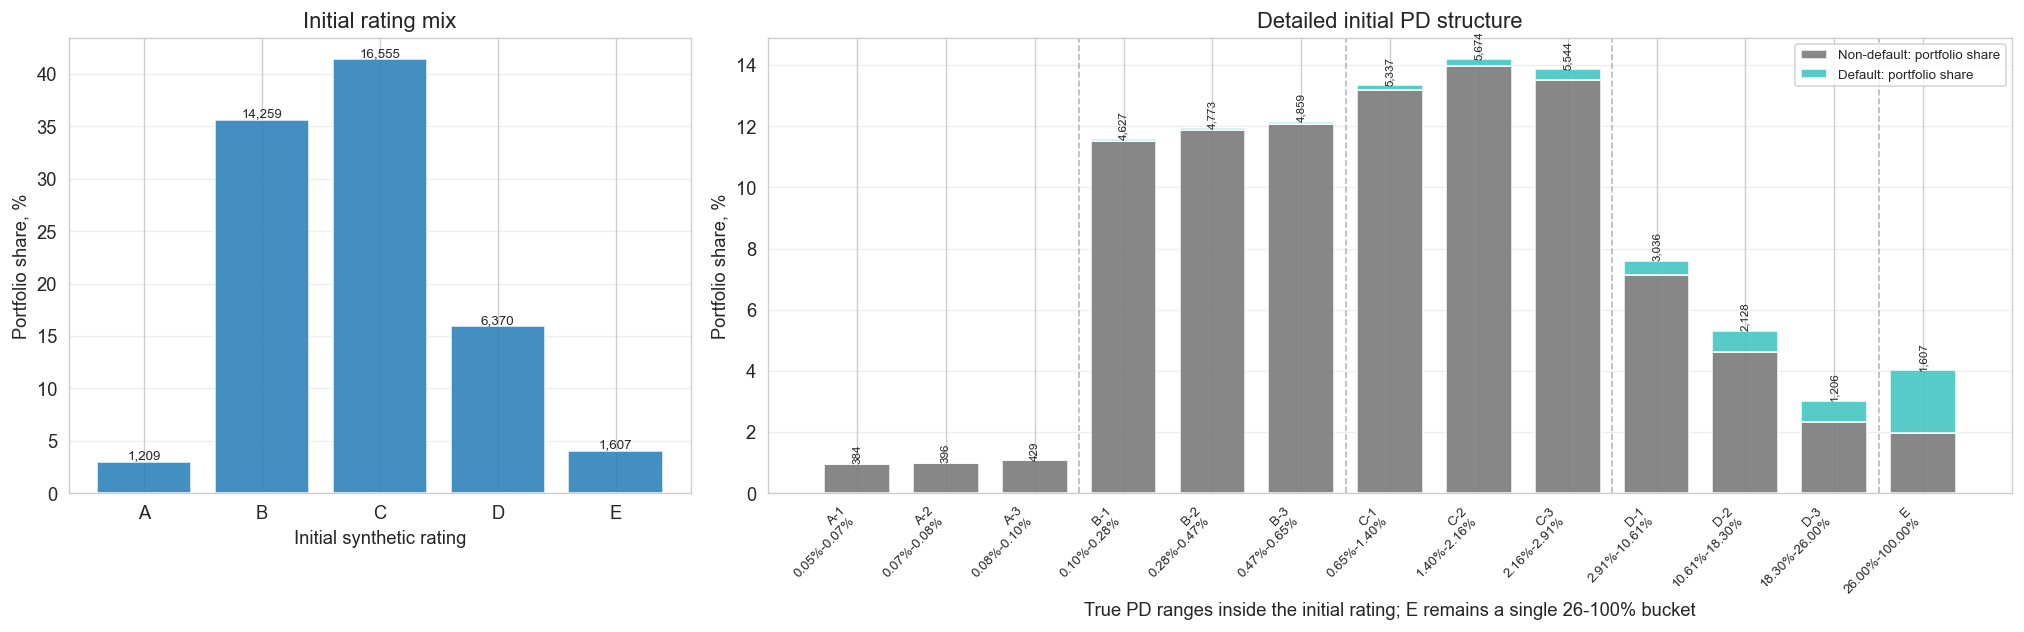

,source_rating,source_pd_band,band_left,band_right,n_assets,asset_share,bad_rate,avg_true_pd
0,A,A-1,0.05%,0.07%,384,0.96%,0.00%,0.06%
1,A,A-2,0.07%,0.08%,396,0.99%,0.00%,0.08%
2,A,A-3,0.08%,0.10%,429,1.07%,0.00%,0.09%
3,B,B-1,0.10%,0.28%,4627,11.57%,0.35%,0.19%
4,B,B-2,0.28%,0.47%,4773,11.93%,0.48%,0.37%
5,B,B-3,0.47%,0.65%,4859,12.15%,0.58%,0.56%
6,C,C-1,0.65%,1.40%,5337,13.34%,1.11%,1.04%
7,C,C-2,1.40%,2.16%,5674,14.19%,1.55%,1.78%
8,C,C-3,2.16%,2.91%,5544,13.86%,2.56%,2.53%
9,D,D-1,2.91%,10.61%,3036,7.59%,6.16%,6.47%


,credit_score,ltv,dti,employment_years,loan_amount,loan_term,num_delinquencies,loan_purpose
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,621.44,0.42,0.32,4.43,231.33,40.88,1.29,1.03
std,89.38,0.17,0.14,2.80,185.04,19.96,1.29,0.87
min,300.00,0.01,0.01,0.00,10.50,12.00,0.00,0.00
25%,562.00,0.30,0.22,2.30,126.40,24.00,0.00,0.00
50%,627.00,0.42,0.31,4.30,184.70,36.00,1.00,1.00
75%,689.00,0.54,0.42,6.30,275.30,48.00,2.00,2.00
max,850.00,1.00,0.93,17.70,4595.40,84.00,11.00,2.00


In [2]:
portfolio_config = get_rating_portfolio_config("stress")
df = generate_credit_data(random_state=RANDOM_STATE, portfolio=portfolio_config.name)

print(f"Portfolio scenario: {portfolio_config.name}")
print(f"Rating mix target: {portfolio_config.rating_mix}")
print(f"Years: {portfolio_config.years}\n")

rating_bounds = pd.DataFrame([
    {
        "rating": rating,
        "pd_lower": PORTFOLIO_RATING_PD_BOUNDS[rating][0],
        "pd_upper": PORTFOLIO_RATING_PD_BOUNDS[rating][1],
        "pd_representative": PORTFOLIO_RATING_PD_BOUNDS[rating][2],
    }
    for rating in portfolio_config.rating_order
])
display(rating_bounds.style.format({"pd_lower": "{:.2%}", "pd_upper": "{:.2%}", "pd_representative": "{:.2%}"}))

print(f"Dataset: {df.shape[0]:,} rows | {df.shape[1]} columns")
print(f"Overall default rate: {df['default'].mean():.2%}")
print(f"Mean true PD in the synthetic data: {df['true_pd'].mean():.2%}\n")

true_pd_stats = df["true_pd"].describe(percentiles=[0.50, 0.90, 0.95, 0.99])[["min", "50%", "90%", "95%", "99%", "max"]]
print("True PD distribution in the portfolio:")
print(true_pd_stats.map(lambda x: f"{x:.2%}"))

segment_stats = (
    df.groupby("rating", sort=False)
      .agg(observations=("default", "count"), default_rate=("default", "mean"), mean_true_pd=("true_pd", "mean"))
      .reindex(portfolio_config.rating_order)
)
segment_map = {rating: rating for rating in portfolio_config.rating_order}
segment_stats.index = segment_stats.index.map(segment_map)
segment_stats["default_rate"] = segment_stats["default_rate"].map("{:.2%}".format)
segment_stats["mean_true_pd"] = segment_stats["mean_true_pd"].map("{:.2%}".format)
print("\nSynthetic portfolio rating structure:")
print(segment_stats)

by_year = df.groupby("origination_year")["default"].agg(total="count", defaults="sum", rate="mean")
by_year["rate"] = by_year["rate"].map("{:.2%}".format)
print("\nDefaults by origination year:")
print(by_year)


def source_rating_summary(
    frame,
    rating_col="rating",
    default_col="default",
    pd_col="true_pd",
    rating_order=PORTFOLIO_RATING_ORDER,
    bounds=PORTFOLIO_RATING_PD_BOUNDS,
):
    summary = (
        frame.groupby(rating_col, observed=False)
        .agg(
            n_assets=(pd_col, "size"),
            defaults=(default_col, "sum"),
            avg_true_pd=(pd_col, "mean"),
        )
        .reindex(rating_order)
        .reset_index()
        .rename(columns={rating_col: "source_rating"})
    )
    summary["n_assets"] = summary["n_assets"].fillna(0).astype(int)
    summary["defaults"] = summary["defaults"].fillna(0).astype(int)
    summary["asset_share"] = summary["n_assets"] / len(frame)
    summary["bad_rate"] = np.where(
        summary["n_assets"] > 0,
        summary["defaults"] / summary["n_assets"],
        np.nan,
    )
    summary["pd_lower"] = summary["source_rating"].map(lambda r: bounds[r][0])
    summary["pd_upper"] = summary["source_rating"].map(lambda r: bounds[r][1])
    summary["pd_representative"] = summary["source_rating"].map(lambda r: bounds[r][2])
    return summary


def source_pd_band_summary(
    frame,
    rating_col="rating",
    default_col="default",
    pd_col="true_pd",
    extra_mean_cols=(),
    rating_order=PORTFOLIO_RATING_ORDER,
    bounds=PORTFOLIO_RATING_PD_BOUNDS,
    n_subbands=3,
):
    rows = []
    for rating in rating_order:
        rating_frame = frame.loc[frame[rating_col] == rating].copy()
        lower, upper, _ = bounds[rating]
        if rating == "E":
            edges = np.array([lower, upper])
        else:
            edges = np.linspace(lower, upper, n_subbands + 1)
        labels = [
            f"{rating}" if rating == "E" else f"{rating}-{i + 1}"
            for i in range(len(edges) - 1)
        ]
        rating_frame["_source_pd_band"] = pd.cut(
            rating_frame[pd_col],
            bins=edges,
            labels=labels,
            include_lowest=True,
            right=True,
        )
        agg_spec = {
            "n_assets": (pd_col, "size"),
            "defaults": (default_col, "sum"),
            "avg_true_pd": (pd_col, "mean"),
        }
        for col in extra_mean_cols:
            agg_spec[f"avg_{col}"] = (col, "mean")
        detail = (
            rating_frame.groupby("_source_pd_band", observed=False)
            .agg(**agg_spec)
            .reindex(labels)
            .reset_index()
            .rename(columns={"_source_pd_band": "source_pd_band"})
        )
        detail["source_rating"] = rating
        detail["band_left"] = edges[:-1]
        detail["band_right"] = edges[1:]
        rows.append(detail)

    detail = pd.concat(rows, ignore_index=True)
    detail["n_assets"] = detail["n_assets"].fillna(0).astype(int)
    detail["defaults"] = detail["defaults"].fillna(0).astype(int)
    detail["non_defaults"] = detail["n_assets"] - detail["defaults"]
    detail["asset_share"] = detail["n_assets"] / len(frame)
    detail["default_portfolio_share"] = detail["defaults"] / len(frame)
    detail["non_default_portfolio_share"] = detail["non_defaults"] / len(frame)
    detail["bad_rate"] = np.where(
        detail["n_assets"] > 0,
        detail["defaults"] / detail["n_assets"],
        np.nan,
    )
    detail["band_label"] = (
        detail["source_pd_band"].astype(str)
        + "\n"
        + detail["band_left"].map("{:.2%}".format)
        + "-"
        + detail["band_right"].map("{:.2%}".format)
    )
    return detail


source_rating_mix = source_rating_summary(df, rating_order=portfolio_config.rating_order)
source_pd_detail = source_pd_band_summary(df, rating_order=portfolio_config.rating_order)

detail_reconciliation = (
    source_pd_detail.groupby("source_rating", observed=False)["n_assets"].sum()
    .reindex(portfolio_config.rating_order)
    .to_numpy()
)
if not np.array_equal(detail_reconciliation, source_rating_mix["n_assets"].to_numpy()):
    raise ValueError("Detailed source PD bands do not reconcile to the source rating mix.")

fig, axes = plt.subplots(1, 2, figsize=(17, 5.4), gridspec_kw={"width_ratios": [0.8, 1.6]})

ax = axes[0]
x = np.arange(len(source_rating_mix))
ax.bar(x, source_rating_mix["asset_share"] * 100, color="#2980b9", alpha=0.88)
for i, row in source_rating_mix.iterrows():
    ax.text(
        i,
        row["asset_share"] * 100,
        f'{int(row["n_assets"]):,}',
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_xticks(x)
ax.set_xticklabels(source_rating_mix["source_rating"])
ax.set_xlabel("Initial synthetic rating")
ax.set_ylabel("Portfolio share, %")
ax.set_title("Initial rating mix")
ax.grid(axis="y", alpha=0.35)

ax = axes[1]
detail_x = np.arange(len(source_pd_detail))
ax.bar(
    detail_x,
    source_pd_detail["non_default_portfolio_share"] * 100,
    width=0.74,
    color="#7a7a7a",
    label="Non-default: portfolio share",
    alpha=0.90,
)
ax.bar(
    detail_x,
    source_pd_detail["default_portfolio_share"] * 100,
    width=0.74,
    bottom=source_pd_detail["non_default_portfolio_share"] * 100,
    color="#48c7c4",
    label="Default: portfolio share",
    alpha=0.92,
)
group_sizes = source_pd_detail.groupby("source_rating", sort=False).size().to_numpy()
for group_end in np.cumsum(group_sizes)[:-1] - 0.5:
    ax.axvline(group_end, color="gray", linestyle="--", lw=1.0, alpha=0.55)
for i, row in source_pd_detail.iterrows():
    if row["n_assets"] > 0:
        ax.text(
            i,
            row["asset_share"] * 100,
            f'{int(row["n_assets"]):,}',
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )
ax.set_xticks(detail_x)
ax.set_xticklabels(source_pd_detail["band_label"], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("True PD ranges inside the initial rating; E remains a single 26-100% bucket")
ax.set_ylabel("Portfolio share, %")
ax.set_title("Detailed initial PD structure")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.35)

plt.tight_layout()
plt.show()

display(
    source_pd_detail[[
        "source_rating", "source_pd_band", "band_left", "band_right",
        "n_assets", "asset_share", "bad_rate", "avg_true_pd",
    ]]
    .style.format({
        "band_left": "{:.2%}",
        "band_right": "{:.2%}",
        "asset_share": "{:.2%}",
        "bad_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
    })
)

display(df.drop(columns=["default", "origination_year", "risk_segment", "true_pd"]).describe().round(2))


### Historical Portfolio Structure by Rating

The portfolio is not reduced to a single average PD. It is reconstructed as `origination year x rating`: number of observations, rating share in the portfolio, average PD, observed default rate, and expected number of defaults. A single aggregate PD is shown only as a top-line figure; the analysis keeps the full portfolio structure.


In [3]:
historical_panel_true = historical_portfolio_panel(df, pd_col="true_pd")
portfolio_avg_true_pd = portfolio_average_pd(df, pd_col="true_pd")

print(f"Aggregate portfolio PD: {portfolio_avg_true_pd:.2%}")
print("This value is only a top-line summary; the analysis below preserves the year x rating structure.")

portfolio_view_cols = [
    "origination_year",
    "rating",
    "n_obs",
    "portfolio_count_share",
    "avg_pd",
    "observed_default_rate",
    "expected_defaults",
    "defaults",
    "calibration_ratio",
]
display(
    historical_panel_true[portfolio_view_cols]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "avg_pd": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)


Aggregate portfolio PD: 4.79%
This value is only a top-line summary; the analysis below preserves the year x rating structure.


,origination_year,rating,n_obs,portfolio_count_share,avg_pd,observed_default_rate,expected_defaults,defaults,calibration_ratio
0,2020,A,221,3.1%,0.08%,0.00%,0.17,0,0.00
1,2020,B,2490,35.1%,0.38%,0.56%,9.45,14,1.48
2,2020,C,2949,41.5%,1.80%,1.46%,53.07,43,0.81
3,2020,D,1145,16.1%,11.75%,11.88%,134.49,136,1.01
4,2020,E,295,4.2%,51.14%,52.54%,150.86,155,1.03
5,2021,A,248,3.3%,0.08%,0.00%,0.19,0,0.00
6,2021,B,2698,35.6%,0.38%,0.44%,10.22,12,1.17
7,2021,C,3129,41.3%,1.78%,1.79%,55.78,56,1.00
8,2021,D,1191,15.7%,11.97%,13.01%,142.53,155,1.09
9,2021,E,304,4.0%,51.80%,50.99%,157.48,155,0.98


### Portfolio Scenario Check: normal vs stress

The project has two portfolio-generation regimes. The main notebook uses `stress`, because its upper PD range is well populated and the RWA impact of calibration is easier to observe. For banking interpretation, it is still useful to see separately that the stress scenario is a deliberately tougher risk distribution, not a random artifact.


In [4]:
scenario_rows = []
for scenario in ["normal", "stress"]:
    scenario_df = generate_credit_data(n_samples=40_000, random_state=RANDOM_STATE, portfolio=scenario)
    summary = portfolio_summary(scenario_df)
    scenario_rows.append({
        "scenario": scenario,
        "n_obs": summary["n_obs"],
        "default_rate": summary["default_rate"],
        "avg_true_pd": summary["avg_true_pd"],
        "p95_true_pd": summary["p95_true_pd"],
        "max_true_pd": summary["max_true_pd"],
    })

scenario_table = pd.DataFrame(scenario_rows).set_index("scenario")
display(
    scenario_table.style.format({
        "default_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "p95_true_pd": "{:.2%}",
        "max_true_pd": "{:.2%}",
    })
)

print("The notebook uses the stress scenario below to test calibration beyond low-PD ranges.")

,n_obs,default_rate,avg_true_pd,p95_true_pd,max_true_pd
scenario,,,,,
normal,40000,2.69%,2.72%,13.32%,99.91%
stress,40000,4.79%,4.79%,22.38%,99.95%


The notebook uses the stress scenario below to test calibration beyond low-PD ranges.


## 3. Experimental Protocol and Sample Split

The experiment uses an **out-of-time setup**: the model and calibrators are fitted on one historical in-time period, while final quality is assessed only on the future OOT portfolio.
- **Train + Calibration (2020-2023)**: shared in-time period for the RF score model and calibration.
- **OOT Test (2024)**: holdout period for metrics, default backtesting, and capital impact.


In [5]:
X_train, X_calib, X_test, y_train, y_calib, y_test = get_oot_split(df)
split_years = sorted(df["origination_year"].unique())
train_calib_label = f"{split_years[0]}-{split_years[-2]}" if len(split_years[:-1]) > 1 else str(split_years[0])
test_label = str(split_years[-1])

print("Out-of-Time split:")
print(f"  Train+Calibration ({train_calib_label}): {len(X_train):,} rows | defaults: {y_train.mean():.2%}")
print(f"  Calibrator fit     ({train_calib_label}): {len(X_calib):,} rows | defaults: {y_calib.mean():.2%}")
print(f"  Test OOT           ({test_label}): {len(X_test):,} rows | defaults: {y_test.mean():.2%}")

Out-of-Time split:
  Train+Calibration (2020-2023): 31,224 rows | defaults: 4.81%
  Calibrator fit     (2020-2023): 31,224 rows | defaults: 4.81%
  Test OOT           (2024): 8,776 rows | defaults: 4.73%


## 4. Base Model and Initial Quality of Uncalibrated PD

This block separates two different scales. The synthetic portfolio already contains an initial rating `A...E` and a hidden `true_pd` that generates defaults. Random Forest does not receive `rating` or `true_pd` as features: it learns only from credit characteristics and the default flag. Its raw `predict_proba` is therefore a score-derived PD estimate, not a calibration model.


In [6]:
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_model.fit(X_train, y_train)

scores_calib = np.clip(base_model.predict_proba(X_calib)[:, 1], 1e-6, 1 - 1e-6)
scores_test  = np.clip(base_model.predict_proba(X_test)[:, 1], 1e-6, 1 - 1e-6)

print(f"RF score range on OOT: [{scores_test.min():.4f}, {scores_test.max():.4f}]")
print(f"Median RF score:         {np.median(scores_test):.4f}")
print(f"90 / 95 / 99 percentiles:   {np.quantile(scores_test, [0.90, 0.95, 0.99]).round(4)}")
print(f"Scores > 0.5:               {(scores_test > 0.5).mean():.1%}")

RF score range on OOT: [0.0031, 0.8679]
Median RF score:         0.0165
90 / 95 / 99 percentiles:   [0.1107 0.257  0.4589]
Scores > 0.5:               0.7%


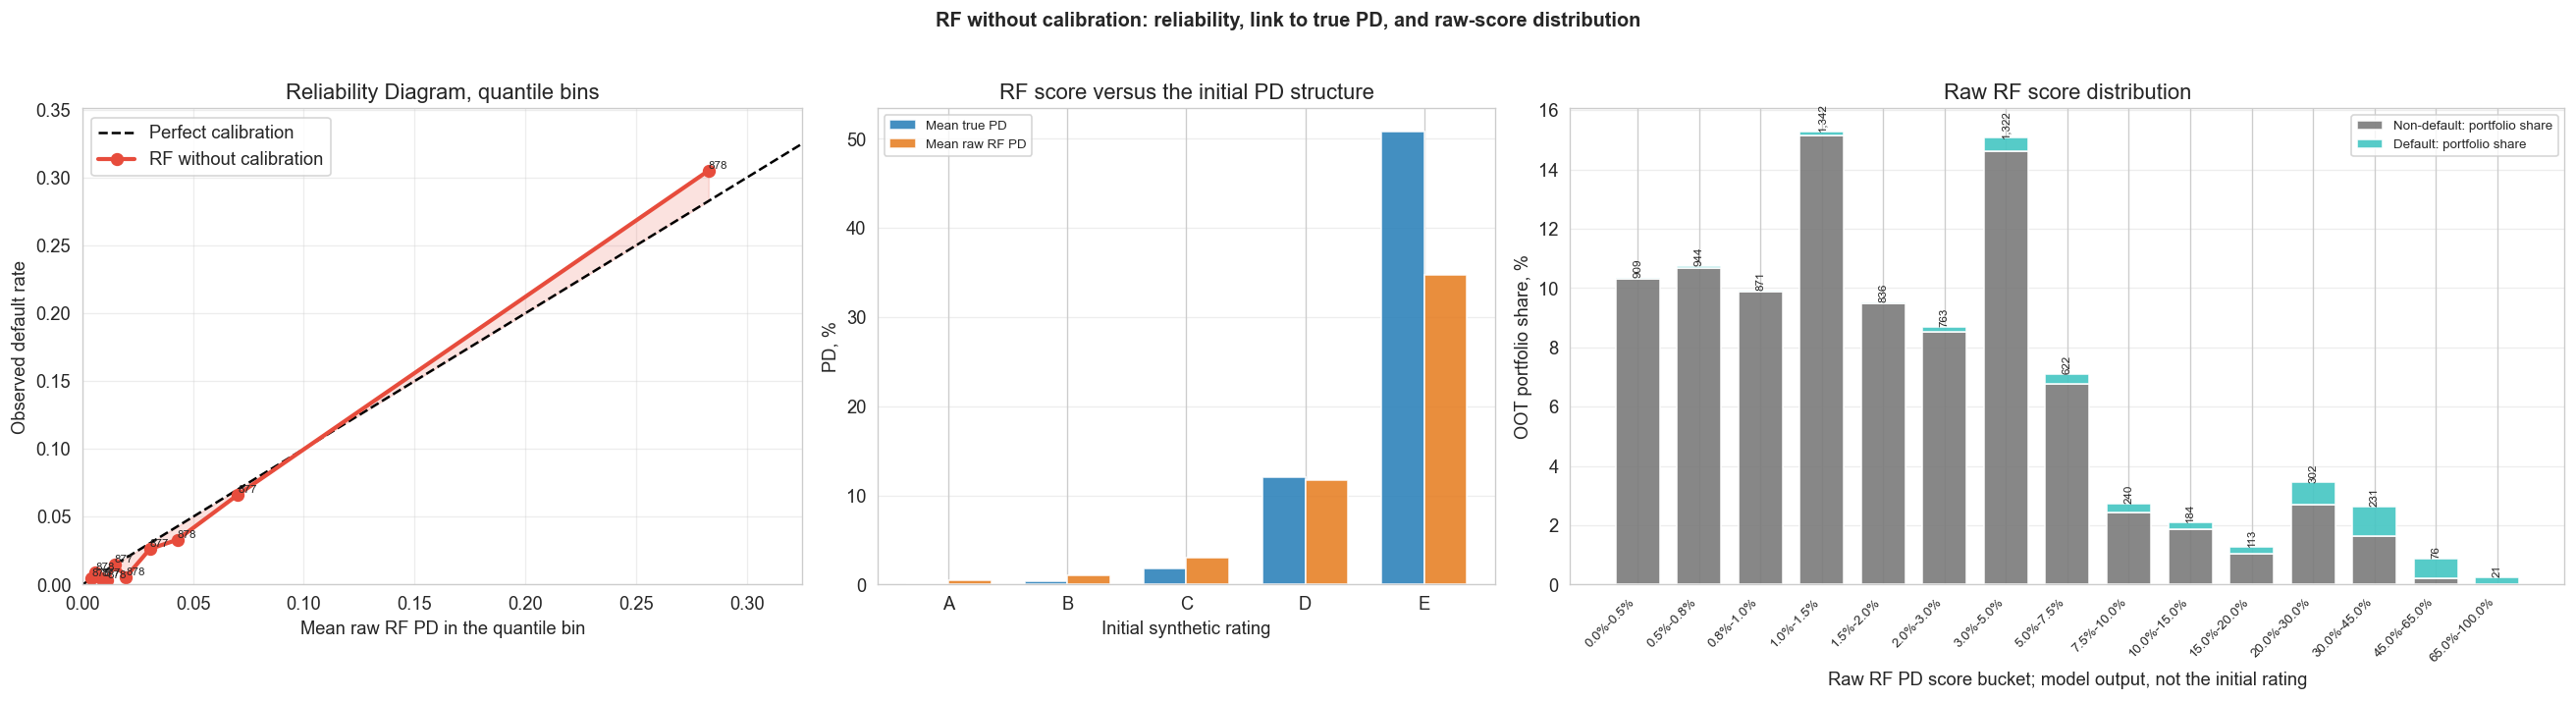

RF does not receive rating/true_pd as features. These fields are used here only to diagnose raw predict_proba quality.
Mean true PD on OOT: 4.83%
Mean raw RF PD on OOT: 4.90%
Minimum raw RF PD: 0.313%
Observations with raw RF PD < 0.05%: 0
Observations with raw RF PD < 0.50%: 909


In [7]:
raw_pd_edges = np.array([
    0.000, 0.005, 0.0075, 0.010, 0.015, 0.020, 0.030,
    0.050, 0.075, 0.100, 0.150, 0.200, 0.300, 0.450, 0.650, 1.000,
])

raw_score_frame = pd.DataFrame({
    "raw_pd": scores_test,
    "default": y_test.values,
    "source_rating": df.loc[y_test.index, "rating"].values,
    "true_pd": df.loc[y_test.index, "true_pd"].values,
}, index=y_test.index)
raw_score_frame["pd_bin"] = pd.cut(
    raw_score_frame["raw_pd"],
    bins=raw_pd_edges,
    include_lowest=True,
    right=True,
)

raw_bin_summary = (
    raw_score_frame.groupby("pd_bin", observed=False)
    .agg(
        n_assets=("raw_pd", "size"),
        defaults=("default", "sum"),
        raw_pd_min_actual=("raw_pd", "min"),
        raw_pd_max_actual=("raw_pd", "max"),
        avg_raw_pd=("raw_pd", "mean"),
        avg_true_pd=("true_pd", "mean"),
    )
    .reset_index()
)
raw_bin_summary["pd_left"] = raw_pd_edges[:-1]
raw_bin_summary["pd_right"] = raw_pd_edges[1:]
raw_bin_summary["pd_width"] = raw_bin_summary["pd_right"] - raw_bin_summary["pd_left"]
raw_bin_summary["non_defaults"] = raw_bin_summary["n_assets"] - raw_bin_summary["defaults"]
raw_bin_summary["bad_rate"] = np.where(
    raw_bin_summary["n_assets"] > 0,
    raw_bin_summary["defaults"] / raw_bin_summary["n_assets"],
    np.nan,
)
raw_bin_summary["asset_share"] = raw_bin_summary["n_assets"] / len(raw_score_frame)
raw_bin_summary["default_portfolio_share"] = raw_bin_summary["defaults"] / len(raw_score_frame)
raw_bin_summary["non_default_portfolio_share"] = raw_bin_summary["non_defaults"] / len(raw_score_frame)

raw_rating_summary = source_rating_summary(
    raw_score_frame,
    rating_col="source_rating",
    default_col="default",
    pd_col="true_pd",
    rating_order=portfolio_config.rating_order,
)
raw_rating_summary["avg_raw_pd"] = (
    raw_score_frame.groupby("source_rating", observed=False)["raw_pd"]
    .mean()
    .reindex(portfolio_config.rating_order)
    .to_numpy()
)

oot_source_pd_detail = source_pd_band_summary(
    raw_score_frame,
    rating_col="source_rating",
    default_col="default",
    pd_col="true_pd",
    extra_mean_cols=("raw_pd",),
    rating_order=portfolio_config.rating_order,
)

rf_reliability = raw_score_frame.copy()
rf_reliability["quantile_bin"] = pd.qcut(
    rf_reliability["raw_pd"],
    q=10,
    duplicates="drop",
)
rf_reliability_summary = (
    rf_reliability.groupby("quantile_bin", observed=True)
    .agg(
        n_assets=("raw_pd", "size"),
        mean_pred=("raw_pd", "mean"),
        observed_default_rate=("default", "mean"),
        avg_true_pd=("true_pd", "mean"),
    )
    .reset_index(drop=True)
)
rf_reliability_summary["abs_calibration_gap"] = (
    rf_reliability_summary["observed_default_rate"]
    - rf_reliability_summary["mean_pred"]
).abs()

rating_x = np.arange(len(raw_rating_summary["source_rating"]))
bin_labels = [
    f"{left:.1%}-{right:.1%}"
    for left, right in zip(raw_pd_edges[:-1], raw_pd_edges[1:])
]
bucket_x = np.arange(len(raw_bin_summary))

fig, axes = plt.subplots(
    1, 3, figsize=(22, 5.8), gridspec_kw={"width_ratios": [1.05, 0.9, 1.45]}
)

ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration")
ax.plot(
    rf_reliability_summary["mean_pred"],
    rf_reliability_summary["observed_default_rate"],
    "o-",
    color=COLORS[0],
    lw=2.5,
    ms=7,
    label="RF without calibration",
)
ax.fill_between(
    rf_reliability_summary["mean_pred"],
    rf_reliability_summary["mean_pred"],
    rf_reliability_summary["observed_default_rate"],
    alpha=0.16,
    color=COLORS[0],
)
for _, row in rf_reliability_summary.iterrows():
    ax.text(
        row["mean_pred"],
        row["observed_default_rate"],
        f'{int(row["n_assets"]):,}',
        fontsize=7,
        ha="left",
        va="bottom",
    )
ax.set_xlim(0, max(0.10, min(1.0, rf_reliability_summary["mean_pred"].max() * 1.15)))
ax.set_ylim(0, max(0.10, min(1.0, rf_reliability_summary["observed_default_rate"].max() * 1.15)))
ax.set_xlabel("Mean raw RF PD in the quantile bin")
ax.set_ylabel("Observed default rate")
ax.set_title("Reliability Diagram, quantile bins")
ax.legend(loc="upper left")
ax.grid(alpha=0.35)

ax = axes[1]
width = 0.36
ax.bar(
    rating_x - width / 2,
    raw_rating_summary["avg_true_pd"] * 100,
    width=width,
    color="#2980b9",
    alpha=0.88,
    label="Mean true PD",
)
ax.bar(
    rating_x + width / 2,
    raw_rating_summary["avg_raw_pd"] * 100,
    width=width,
    color="#e67e22",
    alpha=0.88,
    label="Mean raw RF PD",
)
ax.set_xticks(rating_x)
ax.set_xticklabels(raw_rating_summary["source_rating"])
ax.set_xlabel("Initial synthetic rating")
ax.set_ylabel("PD, %")
ax.set_title("RF score versus the initial PD structure")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.35)

ax = axes[2]
ax.bar(
    bucket_x,
    raw_bin_summary["non_default_portfolio_share"] * 100,
    width=0.72,
    color="#7a7a7a",
    label="Non-default: portfolio share",
    alpha=0.90,
)
ax.bar(
    bucket_x,
    raw_bin_summary["default_portfolio_share"] * 100,
    width=0.72,
    bottom=raw_bin_summary["non_default_portfolio_share"] * 100,
    color="#48c7c4",
    label="Default: portfolio share",
    alpha=0.92,
)
for i, row in raw_bin_summary.iterrows():
    if row["n_assets"] > 0:
        ax.text(
            i,
            row["asset_share"] * 100,
            f'{int(row["n_assets"]):,}',
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )
ax.set_xticks(bucket_x)
ax.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Raw RF PD score bucket; model output, not the initial rating")
ax.set_ylabel("OOT portfolio share, %")
ax.set_title("Raw RF score distribution")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.35)

plt.suptitle(
    "RF without calibration: reliability, link to true PD, and raw-score distribution",
    fontsize=12, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print("RF does not receive rating/true_pd as features. These fields are used here only to diagnose raw predict_proba quality.")
print(f"Mean true PD on OOT: {raw_score_frame['true_pd'].mean():.2%}")
print(f"Mean raw RF PD on OOT: {raw_score_frame['raw_pd'].mean():.2%}")
print(f"Minimum raw RF PD: {raw_score_frame['raw_pd'].min():.3%}")
print(f"Observations with raw RF PD < 0.05%: {(raw_score_frame['raw_pd'] < 0.0005).sum():,}")
print(f"Observations with raw RF PD < 0.50%: {(raw_score_frame['raw_pd'] < 0.0050).sum():,}")


The tables below separate the original OOT portfolio structure from the model output. `raw RF score buckets` include the actual minimum and maximum raw PD inside each bucket. This matters because a bucket such as `0.0%-0.5%` is a broad interval up to half a percent, not a claim that all observations have PD below `0.05%`.


In [8]:
rating_display_cols = [
    "source_rating", "pd_lower", "pd_upper", "pd_representative",
    "n_assets", "asset_share", "bad_rate", "avg_true_pd", "avg_raw_pd",
]
display(
    raw_rating_summary[rating_display_cols]
    .style.format({
        "pd_lower": "{:.3%}",
        "pd_upper": "{:.3%}",
        "pd_representative": "{:.3%}",
        "asset_share": "{:.2%}",
        "bad_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "avg_raw_pd": "{:.2%}",
    })
)

detail_display_cols = [
    "source_rating", "source_pd_band", "band_left", "band_right",
    "n_assets", "asset_share", "bad_rate", "avg_true_pd", "avg_raw_pd",
]
display(
    oot_source_pd_detail[detail_display_cols]
    .style.format({
        "band_left": "{:.2%}",
        "band_right": "{:.2%}",
        "asset_share": "{:.2%}",
        "bad_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "avg_raw_pd": "{:.2%}",
    })
)

display(
    rf_reliability_summary.style.format({
        "mean_pred": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "abs_calibration_gap": "{:.2%}",
    })
)

raw_bucket_display_cols = [
    "pd_left", "pd_right", "pd_width", "n_assets", "defaults",
    "bad_rate", "raw_pd_min_actual", "raw_pd_max_actual",
    "avg_true_pd", "avg_raw_pd", "asset_share",
]
display(
    raw_bin_summary[raw_bucket_display_cols].style.format({
        "pd_left": "{:.3%}",
        "pd_right": "{:.3%}",
        "pd_width": "{:.3%}",
        "bad_rate": "{:.2%}",
        "raw_pd_min_actual": "{:.3%}",
        "raw_pd_max_actual": "{:.3%}",
        "avg_true_pd": "{:.2%}",
        "avg_raw_pd": "{:.2%}",
        "asset_share": "{:.2%}",
    })
)


,source_rating,pd_lower,pd_upper,pd_representative,n_assets,asset_share,bad_rate,avg_true_pd,avg_raw_pd
0,A,0.050%,0.100%,0.075%,257,2.93%,0.00%,0.08%,0.53%
1,B,0.100%,0.650%,0.350%,3134,35.71%,0.41%,0.38%,1.00%
2,C,0.650%,2.910%,1.780%,3619,41.24%,1.80%,1.80%,3.05%
3,D,2.910%,26.000%,9.500%,1421,16.19%,10.98%,12.04%,11.75%
4,E,26.000%,100.000%,40.000%,345,3.93%,52.46%,50.87%,34.77%


,source_rating,source_pd_band,band_left,band_right,n_assets,asset_share,bad_rate,avg_true_pd,avg_raw_pd
0,A,A-1,0.05%,0.07%,80,0.91%,0.00%,0.06%,0.41%
1,A,A-2,0.07%,0.08%,82,0.93%,0.00%,0.07%,0.47%
2,A,A-3,0.08%,0.10%,95,1.08%,0.00%,0.09%,0.67%
3,B,B-1,0.10%,0.28%,991,11.29%,0.50%,0.20%,0.51%
4,B,B-2,0.28%,0.47%,1023,11.66%,0.59%,0.37%,0.81%
5,B,B-3,0.47%,0.65%,1120,12.76%,0.18%,0.56%,1.62%
6,C,C-1,0.65%,1.40%,1157,13.18%,1.30%,1.04%,1.11%
7,C,C-2,1.40%,2.16%,1233,14.05%,1.30%,1.79%,2.45%
8,C,C-3,2.16%,2.91%,1229,14.00%,2.77%,2.53%,5.49%
9,D,D-1,2.91%,10.61%,664,7.57%,6.02%,6.44%,4.62%


,n_assets,mean_pred,observed_default_rate,avg_true_pd,abs_calibration_gap
0,878,0.41%,0.46%,0.19%,0.04%
1,878,0.60%,0.91%,0.41%,0.31%
2,877,0.85%,0.46%,0.61%,0.39%
3,878,1.11%,0.34%,0.79%,0.77%
4,877,1.45%,1.48%,1.10%,0.03%
5,878,1.97%,0.57%,1.70%,1.40%
6,877,3.05%,2.62%,2.62%,0.42%
7,878,4.28%,3.30%,3.82%,0.98%
8,877,7.01%,6.61%,7.35%,0.40%
9,878,28.28%,30.52%,29.70%,2.24%


,pd_left,pd_right,pd_width,n_assets,defaults,bad_rate,raw_pd_min_actual,raw_pd_max_actual,avg_true_pd,avg_raw_pd,asset_share
0,0.000%,0.500%,0.500%,909,4,0.44%,0.313%,0.500%,0.20%,0.42%,10.36%
1,0.500%,0.750%,0.250%,944,8,0.85%,0.500%,0.750%,0.43%,0.61%,10.76%
2,0.750%,1.000%,0.250%,871,4,0.46%,0.750%,1.000%,0.63%,0.87%,9.92%
3,1.000%,1.500%,0.500%,1342,12,0.89%,1.000%,1.500%,0.92%,1.23%,15.29%
4,1.500%,2.000%,0.500%,836,5,0.60%,1.500%,2.000%,1.39%,1.73%,9.53%
5,2.000%,3.000%,1.000%,763,16,2.10%,2.003%,2.998%,2.20%,2.44%,8.69%
6,3.000%,5.000%,2.000%,1322,40,3.03%,3.001%,4.996%,3.44%,3.93%,15.06%
7,5.000%,7.500%,2.500%,622,28,4.50%,5.001%,7.499%,6.06%,6.03%,7.09%
8,7.500%,10.000%,2.500%,240,27,11.25%,7.503%,9.986%,9.27%,8.57%,2.73%
9,10.000%,15.000%,5.000%,184,21,11.41%,10.008%,14.984%,12.97%,12.22%,2.10%


Random Forest does not directly take PD from the synthetic portfolio. In `get_oot_split`, `rating`, `risk_segment`, and `true_pd` are excluded from the features, so the model sees only credit characteristics and the default flag. Raw `predict_proba` should be close to the hidden risk structure when the features recover it well, but it remains a separate model estimate rather than the original scale.


## 5. Training and Checking PD Calibrators

All calibrators receive the same input: the raw PD of the base RF model (`scores_calib`). The target for fitting is the observed in-time default flag (`y_calib`). After training, each calibrator is applied only to `scores_test`, so the OOT comparison remains clean.


In [9]:
calibrators = get_all_calibrators()
calibrated_probs = {}
calibrated_probs_calib = {}

score_grid = np.linspace(
    max(1e-6, float(np.quantile(scores_calib, 0.001))),
    min(1.0 - 1e-6, float(np.quantile(scores_calib, 0.999))),
    500,
)

calibration_audit_rows = []
for name, cal in calibrators.items():
    cal.fit(scores_calib, y_calib.values)
    pred_calib = np.clip(cal.predict(scores_calib), 1e-6, 1 - 1e-6)
    pred_test = np.clip(cal.predict(scores_test), 1e-6, 1 - 1e-6)
    grid_pred = np.clip(cal.predict(score_grid), 1e-6, 1 - 1e-6)

    calibrated_probs_calib[name] = pred_calib
    calibrated_probs[name] = pred_test

    calibration_audit_rows.append({
        "method": name,
        "fit_input": "scores_calib",
        "fit_target": "y_calib",
        "predict_input": "scores_test",
        "n_fit": len(scores_calib),
        "n_predict": len(pred_test),
        "fit_default_rate": float(y_calib.mean()),
        "mean_pred_calib": float(pred_calib.mean()),
        "mean_pred_oot": float(pred_test.mean()),
        "min_pred_oot": float(pred_test.min()),
        "max_pred_oot": float(pred_test.max()),
        "finite": bool(np.isfinite(pred_test).all()),
        "inside_0_1": bool(((pred_test > 0.0) & (pred_test < 1.0)).all()),
        "monotone_on_grid": bool(np.all(np.diff(grid_pred) >= -1e-8)),
    })
    print(f"{name}: trained and checked.")

calibration_audit = pd.DataFrame(calibration_audit_rows).set_index("method")

if not calibration_audit[["finite", "inside_0_1", "monotone_on_grid"]].all().all():
    raise ValueError("Calibration audit failed: check finite/probability/monotonicity columns.")
if not (calibration_audit["n_predict"] == len(y_test)).all():
    raise ValueError("Calibration audit failed: prediction length does not match OOT target length.")

print(f"Calibrators were fitted on the shared in-time period {train_calib_label}.")
print("Check: fit = scores_calib + y_calib, predict = scores_test.")

display(
    calibration_audit.style.format({
        "fit_default_rate": "{:.2%}",
        "mean_pred_calib": "{:.2%}",
        "mean_pred_oot": "{:.2%}",
        "min_pred_oot": "{:.2%}",
        "max_pred_oot": "{:.2%}",
    })
)


Logit calibration: trained and checked.
Isotonic regression: trained and checked.


Beta calibration: trained and checked.
Monotone spline: trained and checked.
French spline: trained and checked.
Calibrators were fitted on the shared in-time period 2020-2023.
Check: fit = scores_calib + y_calib, predict = scores_test.


,fit_input,fit_target,predict_input,n_fit,n_predict,fit_default_rate,mean_pred_calib,mean_pred_oot,min_pred_oot,max_pred_oot,finite,inside_0_1,monotone_on_grid
method,,,,,,,,,,,,,
Logit calibration,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.81%,4.91%,0.15%,93.53%,True,True,True
Isotonic regression,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.81%,4.91%,0.00%,100.00%,True,True,True
Beta calibration,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.81%,4.90%,0.18%,96.61%,True,True,True
Monotone spline,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.55%,4.67%,0.14%,52.12%,True,True,True
French spline,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.58%,4.70%,0.15%,51.89%,True,True,True


Comparison of monotone and French splines:
Mean absolute difference: 0.006401
Maximum absolute difference: 0.017383


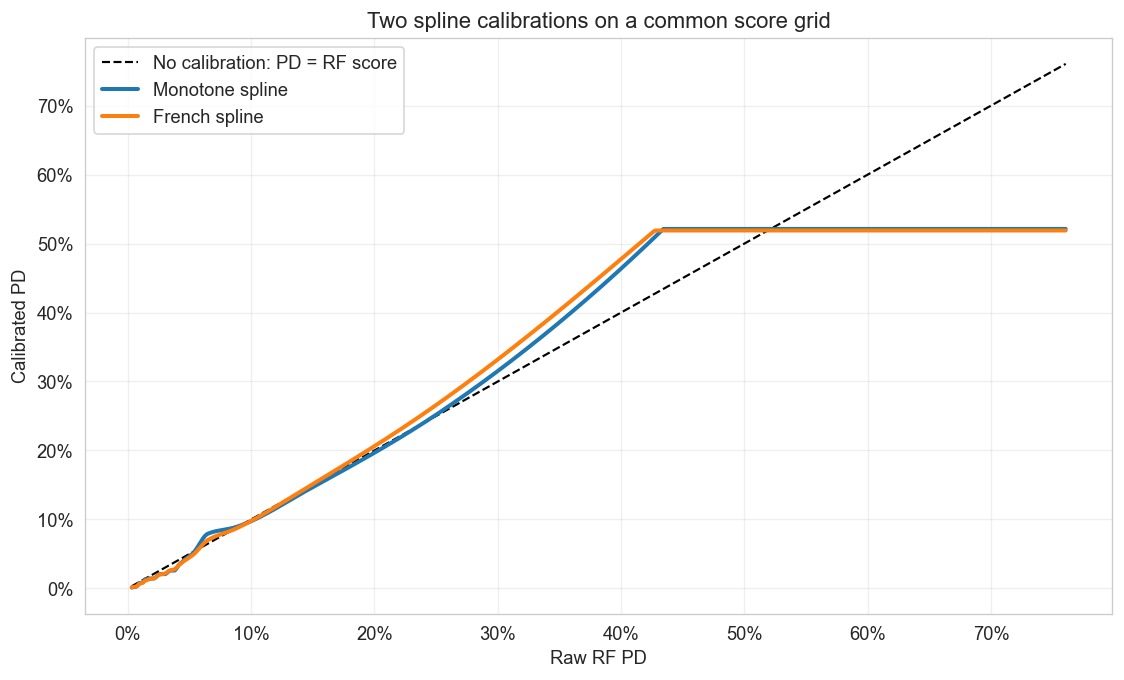

In [10]:
mono = calibrators["Monotone spline"]
french = calibrators["French spline"]

mono_pd = mono.predict(score_grid)
french_pd = french.predict(score_grid)
diff = np.abs(mono_pd - french_pd)

print("Comparison of monotone and French splines:")
print(f"Mean absolute difference: {diff.mean():.6f}")
print(f"Maximum absolute difference: {diff.max():.6f}")

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.plot(score_grid, score_grid, "--", color="black", lw=1.3, label="No calibration: PD = RF score")
ax.plot(score_grid, mono_pd, label="Monotone spline", linewidth=2.4)
ax.plot(score_grid, french_pd, label="French spline", linewidth=2.4)
ax.set_xlabel("Raw RF PD")
ax.set_ylabel("Calibrated PD")
ax.set_title("Two spline calibrations on a common score grid")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Spline calibrations use the same in-time information but differ mathematically. The plain monotone spline smooths empirical default rates as a function of the raw score, while the French variant first stabilizes the level through logit calibration and then smooths the residual correction. Their curves may look close, but they are not duplicate implementations of the same object.


### Calibration Function Shape Check

This chart shows the **mathematical function** learned by each calibrator: `raw RF PD -> calibrated PD`. Monotonicity is required by the meaning of PD: if the original RF score is higher, the calibrated PD should not become lower. Isotonic regression is also monotone, but its function is stepwise; splines are used to obtain a smoother PD scale.


In [11]:
print("Metrics, reliability charts, and the bootstrap check are computed in the next section. The final method choice is made after the statistical and RWA blocks.")


Metrics, reliability charts, and the bootstrap check are computed in the next section. The final method choice is made after the statistical and RWA blocks.


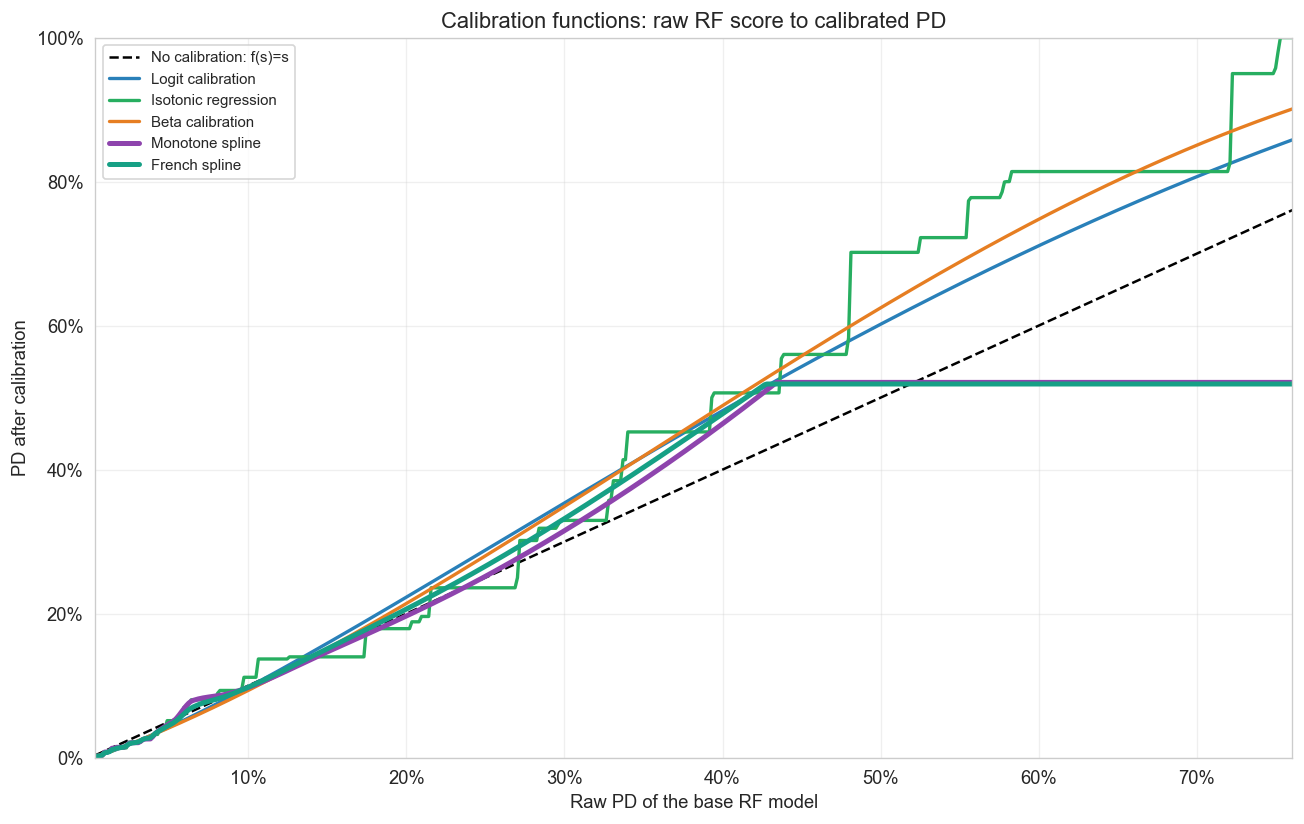

The chart range is limited to the 0.1% and 99.9% calibration-score percentiles so rare extremes do not compress the main area.


In [12]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(score_grid, score_grid, "k--", lw=1.5, label="No calibration: f(s)=s")

for (name, cal), color in zip(calibrators.items(), COLORS[1:]):
    calibrated_grid = cal.predict(score_grid)
    lw = 3.0 if "spline" in name.lower() else 2.0
    ax.plot(score_grid, calibrated_grid, color=color, lw=lw, label=name)

ax.set_xlabel("Raw PD of the base RF model")
ax.set_ylabel("PD after calibration")
ax.set_title("Calibration functions: raw RF score to calibrated PD")
ax.set_xlim(score_grid.min(), score_grid.max())
ax.set_ylim(0, min(1.0, max(max(cal.predict(score_grid)) for cal in calibrators.values()) * 1.10))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The chart range is limited to the 0.1% and 99.9% calibration-score percentiles so rare extremes do not compress the main area.")


In [13]:
parameter_rows = []
for name, cal in calibrators.items():
    row = {"Method": name}

    if hasattr(cal, "_model") and hasattr(cal._model, "coef_"):
        row["Parameters"] = (
            f"a={float(cal._model.coef_[0][0]):.4f}, "
            f"b={float(cal._model.intercept_[0]):.4f}"
        )
    elif hasattr(cal, "a_"):
        row["Parameters"] = (
            f"a={cal.a_:.4f}, b={cal.b_:.4f}, c={cal.c_:.4f}, "
            f"success={cal.success_}"
        )
    elif hasattr(cal, "bin_stats_") and cal.bin_stats_ is not None:
        row["Parameters"] = f"number of bins={len(cal.bin_stats_)}"
    else:
        row["Parameters"] = "non-parametric method"

    parameter_rows.append(row)

display(pd.DataFrame(parameter_rows).set_index("Method"))


,Parameters
Method,
Logit calibration,"a=1.1993, b=0.4135"
Isotonic regression,non-parametric method
Beta calibration,"a=1.1192, b=-1.6697, c=0.1280, success=True"
Monotone spline,number of bins=30
French spline,number of bins=30


## 6. OOT Results, Reliability, and Stability

All methods are compared on the same 2024 OOT portfolio. The statistical metrics summarize two aspects: ranking quality (`roc_auc`, `average_precision`) and probability quality (`brier`, `log_loss`, `calibration_error`, `mean_pd`).


**How to read reliability charts.**

Each point is a quantile bin of borrowers sorted by predicted PD. The x-axis is average predicted PD, and the y-axis is the observed default rate. A well-calibrated method should stay close to the diagonal and avoid systematic underprediction or overprediction in high-risk bins.


In [14]:
results = [summary_metrics(y_test.values, scores_test, name="RF without calibration")]
for name, probs in calibrated_probs.items():
    results.append(summary_metrics(y_test.values, probs, name=name))

df_results = pd.DataFrame(results).set_index("method")

print("Metrics on the 2024 OOT sample:")
print("  Brier Score, Log-Loss, ECE  — lower is better")
print("  HL p-value                  — higher is better, although with large n the test is often too strict")
print("  Slope ~ 1, Intercept ~ 0    — closer to perfect calibration")

df_results_ru = df_results.rename(columns={
    "brier_score": "Brier Score",
    "log_loss": "Log-Loss",
    "ece_uniform": "ECE (fixed bins)",
    "ece_quantile": "ECE (quantile bins)",
    "hl_chi2": "HL chi2",
    "hl_p_value": "HL p-value",
    "cal_slope": "Cal. slope",
    "cal_intercept": "Cal. intercept",
})

display(
    df_results_ru.round({
        "Brier Score": 5,
        "Log-Loss": 5,
        "ECE (fixed bins)": 5,
        "ECE (quantile bins)": 5,
        "HL chi2": 3,
        "HL p-value": 4,
        "Cal. slope": 4,
        "Cal. intercept": 4,
    })
)

disc_rows = []
all_preds = {"RF without calibration": scores_test, **calibrated_probs}
all_methods = all_preds
for name, probs in all_preds.items():
    disc_rows.append(discrimination_metrics(y_test.values, probs, name=name))

df_disc = pd.DataFrame(disc_rows).set_index("method")
print("\nRanking metrics (AUC / Gini / KS):")
display(df_disc)
print("Comment: strictly monotone transformations usually preserve ranking;")
print("isotonic and spline calibration can slightly change AUC/Gini because of ties or smoothing.")

prob_range_rows = []
for name, probs in all_preds.items():
    prob_range_rows.append({
        "method": name,
        "min_pd": np.min(probs),
        "p95_pd": np.quantile(probs, 0.95),
        "max_pd": np.max(probs),
        "mean_pd": np.mean(probs),
    })

df_prob_ranges = pd.DataFrame(prob_range_rows).set_index("method")
df_prob_ranges_ru = df_prob_ranges.rename(columns={
    "min_pd": "Min PD",
    "p95_pd": "95th percentile PD",
    "max_pd": "Max PD",
    "mean_pd": "Mean PD",
})
print("\nActual PD range on OOT:")
display(df_prob_ranges_ru.style.format("{:.2%}"))


Metrics on the 2024 OOT sample:
  Brier Score, Log-Loss, ECE  — lower is better
  HL p-value                  — higher is better, although with large n the test is often too strict
  Slope ~ 1, Intercept ~ 0    — closer to perfect calibration


,Brier Score,Log-Loss,ece,ECE (fixed bins),ECE (quantile bins),HL chi2,HL p-value,Cal. slope,Cal. intercept
method,,,,,,,,,
RF without calibration,0.03430,0.13138,0.00699,0.00784,0.00699,22.982,0.0034,1.1552,0.2747
Logit calibration,0.03408,0.13060,0.00572,0.00554,0.00572,24.188,0.0021,0.9630,-0.1243
Isotonic regression,0.03402,0.13332,0.00468,0.00297,0.00468,70.244,0.0000,0.9129,-0.2289
Beta calibration,0.03400,0.13037,0.00580,0.00529,0.00580,21.154,0.0068,0.9657,-0.1191
Monotone spline,0.03459,0.13207,0.00591,0.00577,0.00591,34.364,0.0000,1.0386,0.0949
French spline,0.03464,0.13196,0.00457,0.00527,0.00457,28.652,0.0004,1.0174,0.0427



Ranking metrics (AUC / Gini / KS):


,auc_roc,gini,ks_stat
method,,,
RF without calibration,0.8786,0.7572,0.6219
Logit calibration,0.8786,0.7572,0.6219
Isotonic regression,0.8789,0.7578,0.6196
Beta calibration,0.8786,0.7572,0.6219
Monotone spline,0.8783,0.7566,0.6219
French spline,0.8785,0.7569,0.6219


Comment: strictly monotone transformations usually preserve ranking;
isotonic and spline calibration can slightly change AUC/Gini because of ties or smoothing.

Actual PD range on OOT:


,Min PD,95th percentile PD,Max PD,Mean PD
method,,,,
RF without calibration,0.31%,25.70%,86.79%,4.90%
Logit calibration,0.15%,29.74%,93.53%,4.91%
Isotonic regression,0.00%,23.59%,100.00%,4.91%
Beta calibration,0.18%,28.97%,96.61%,4.90%
Monotone spline,0.14%,26.02%,52.12%,4.67%
French spline,0.15%,27.47%,51.89%,4.70%


### Bootstrap Stability Check

Bootstrap intervals show how stable the quality metrics are under resampling of the OOT portfolio. This helps distinguish a real method advantage from a small sample fluctuation.


In [15]:
from sklearn.metrics import roc_auc_score

boot_rows = []

print("Bootstrap 95% CI (1000 iterations) on OOT Test...")
print(f"{'Method':<28} {'Brier':>7}  {'95% CI Brier':>18}  {'AUC':>7}  {'95% CI AUC':>18}")
print("-" * 85)

for name, probs in all_preds.items():
    ci_brier = bootstrap_ci(y_test.values, probs, brier_score,   n_iter=1000, random_state=42)
    ci_auc   = bootstrap_ci(y_test.values, probs, roc_auc_score, n_iter=1000, random_state=42)

    boot_rows.append({
        "method": name,
        "brier_point": ci_brier["point_estimate"],
        "brier_ci_lower": ci_brier["ci_lower"],
        "brier_ci_upper": ci_brier["ci_upper"],
        "auc_point": ci_auc["point_estimate"],
        "auc_ci_lower": ci_auc["ci_lower"],
        "auc_ci_upper": ci_auc["ci_upper"],
    })

    print(
        f"{name:<28} "
        f"{ci_brier['point_estimate']:>7.5f}  "
        f"[{ci_brier['ci_lower']:.5f}, {ci_brier['ci_upper']:.5f}]  "
        f"{ci_auc['point_estimate']:>7.4f}  "
        f"[{ci_auc['ci_lower']:.4f}, {ci_auc['ci_upper']:.4f}]"
    )

df_boot = pd.DataFrame(boot_rows).set_index("method")

print("\nInterpretation: if Brier intervals overlap strongly, differences between methods are small.")


Bootstrap 95% CI (1000 iterations) on OOT Test...
Method                         Brier        95% CI Brier      AUC          95% CI AUC
-------------------------------------------------------------------------------------


RF without calibration       0.03430  [0.03118, 0.03735]   0.8786  [0.8597, 0.8971]


Logit calibration            0.03408  [0.03099, 0.03707]   0.8786  [0.8597, 0.8971]


Isotonic regression          0.03402  [0.03083, 0.03707]   0.8789  [0.8605, 0.8965]


Beta calibration             0.03400  [0.03090, 0.03699]   0.8786  [0.8597, 0.8971]


Monotone spline              0.03459  [0.03148, 0.03761]   0.8783  [0.8596, 0.8966]


French spline                0.03464  [0.03156, 0.03765]   0.8785  [0.8595, 0.8969]

Interpretation: if Brier intervals overlap strongly, differences between methods are small.


### Reliability Charts and Bin Distribution

The reliability tables below are later reused for the binomial z-stat diagnostics. They keep the number of observations, defaults, observed default rate, average predicted PD, and confidence bounds for each bin.


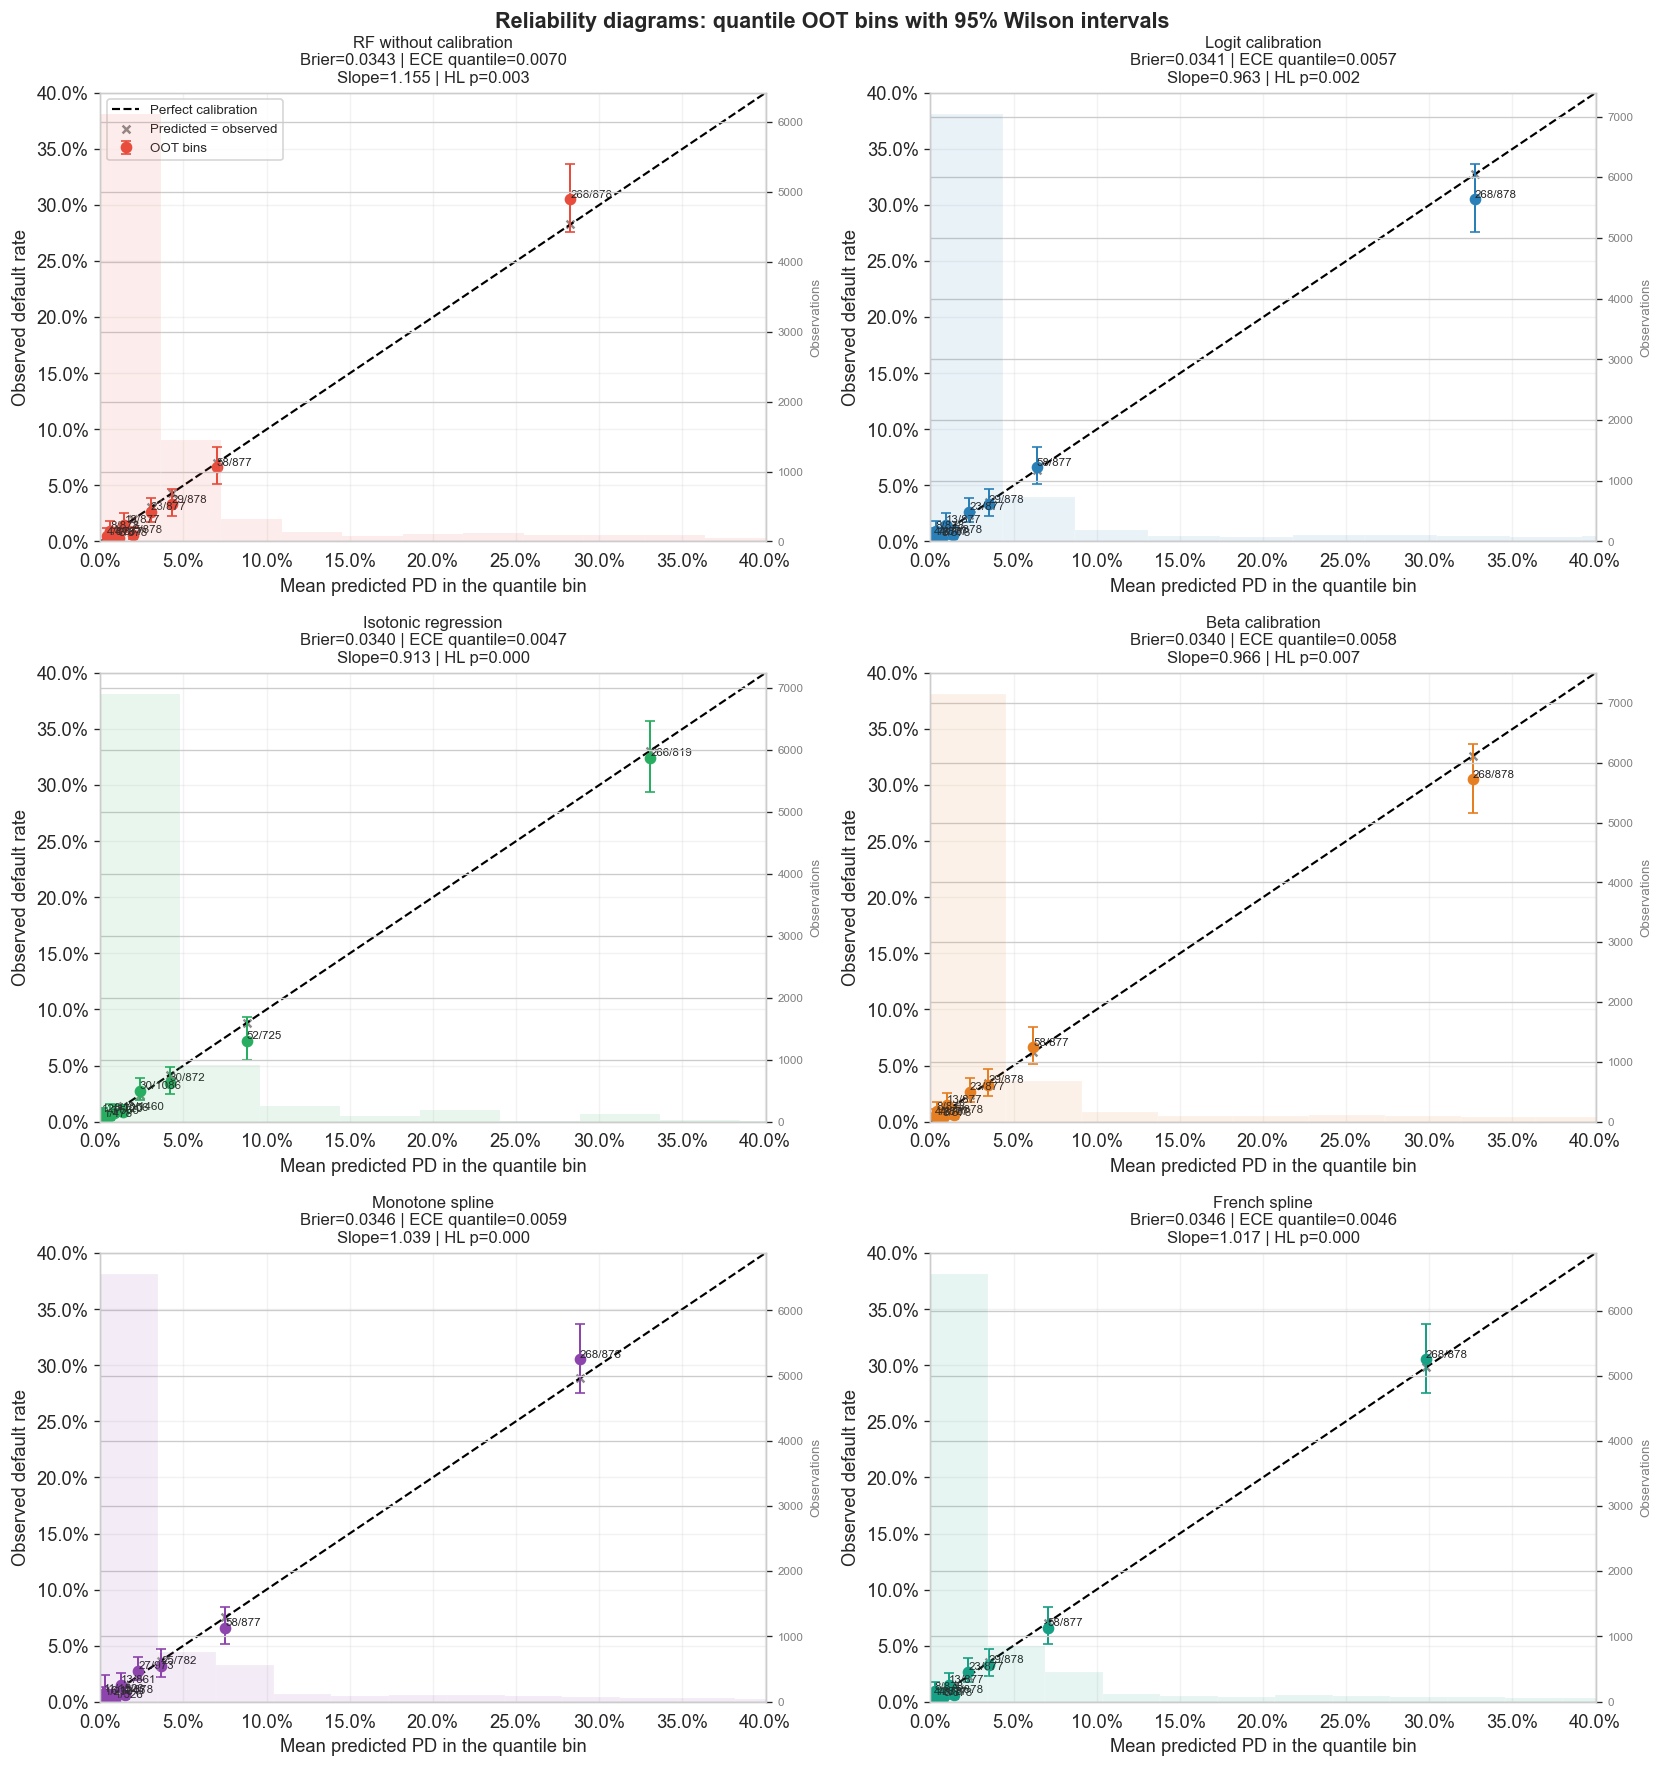

Reliability tables by method:

RF without calibration


,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,878,0.41%,0.46%,4.000000,0.04%,0.18%,1.17%,0.71%
1,878,0.60%,0.91%,8.000000,0.31%,0.46%,1.79%,0.88%
2,877,0.85%,0.46%,4.000000,0.39%,0.18%,1.17%,0.71%
3,878,1.11%,0.34%,3.000000,0.77%,0.12%,1.00%,0.66%
4,877,1.45%,1.48%,13.000000,0.03%,0.87%,2.52%,1.04%
5,878,1.97%,0.57%,5.000000,1.40%,0.24%,1.33%,0.76%
6,877,3.05%,2.62%,23.000000,0.42%,1.75%,3.90%,1.28%
7,878,4.28%,3.30%,29.000000,0.98%,2.31%,4.70%,1.40%
8,877,7.01%,6.61%,58.000000,0.40%,5.15%,8.45%,1.84%
9,878,28.28%,30.52%,268.000000,2.24%,27.57%,33.65%,3.13%



Logit calibration


,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,878,0.21%,0.46%,4.000000,0.25%,0.18%,1.17%,0.71%
1,878,0.33%,0.91%,8.000000,0.58%,0.46%,1.79%,0.88%
2,877,0.50%,0.46%,4.000000,0.04%,0.18%,1.17%,0.71%
3,878,0.69%,0.34%,3.000000,0.35%,0.12%,1.00%,0.66%
4,877,0.95%,1.48%,13.000000,0.53%,0.87%,2.52%,1.04%
5,878,1.38%,0.57%,5.000000,0.81%,0.24%,1.33%,0.76%
6,877,2.33%,2.62%,23.000000,0.29%,1.75%,3.90%,1.28%
7,878,3.52%,3.30%,29.000000,0.22%,2.31%,4.70%,1.40%
8,877,6.41%,6.61%,58.000000,0.20%,5.15%,8.45%,1.84%
9,878,32.77%,30.52%,268.000000,2.25%,27.57%,33.65%,3.13%



Isotonic regression


...

,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,878,0.25%,0.46%,4.000000,0.21%,0.18%,1.17%,0.71%
1,878,0.37%,0.91%,8.000000,0.54%,0.46%,1.79%,0.88%
2,877,0.55%,0.46%,4.000000,0.09%,0.18%,1.17%,0.71%
3,878,0.75%,0.34%,3.000000,0.41%,0.12%,1.00%,0.66%
4,877,1.01%,1.48%,13.000000,0.47%,0.87%,2.52%,1.04%
5,878,1.43%,0.57%,5.000000,0.86%,0.24%,1.33%,0.76%
6,877,2.35%,2.62%,23.000000,0.27%,1.75%,3.90%,1.28%
7,878,3.48%,3.30%,29.000000,0.17%,2.31%,4.70%,1.40%
8,877,6.19%,6.61%,58.000000,0.43%,5.15%,8.45%,1.84%
9,878,32.65%,30.52%,268.000000,2.13%,27.57%,33.65%,3.13%



Monotone spline


,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,1526,0.18%,0.72%,11.000000,0.54%,0.40%,1.29%,0.57%
1,230,0.27%,0.43%,1.000000,0.16%,0.08%,2.42%,1.99%
2,1245,0.61%,0.48%,6.000000,0.13%,0.22%,1.05%,0.57%
3,526,0.87%,0.19%,1.000000,0.68%,0.03%,1.07%,0.88%
4,861,1.26%,1.51%,13.000000,0.25%,0.88%,2.57%,1.06%
5,878,1.48%,0.57%,5.000000,0.91%,0.24%,1.33%,0.76%
6,973,2.29%,2.77%,27.000000,0.48%,1.91%,4.01%,1.23%
7,782,3.66%,3.20%,25.000000,0.47%,2.17%,4.68%,1.48%
8,877,7.53%,6.61%,58.000000,0.92%,5.15%,8.45%,1.84%
9,878,28.85%,30.52%,268.000000,1.67%,27.57%,33.65%,3.13%



French spline


,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,878,0.18%,0.46%,4.000000,0.28%,0.18%,1.17%,0.71%
1,878,0.26%,0.91%,8.000000,0.65%,0.46%,1.79%,0.88%
2,877,0.52%,0.46%,4.000000,0.06%,0.18%,1.17%,0.71%
3,878,0.77%,0.34%,3.000000,0.43%,0.12%,1.00%,0.66%
4,877,1.12%,1.48%,13.000000,0.36%,0.87%,2.52%,1.04%
5,878,1.44%,0.57%,5.000000,0.87%,0.24%,1.33%,0.76%
6,877,2.29%,2.62%,23.000000,0.34%,1.75%,3.90%,1.28%
7,878,3.53%,3.30%,29.000000,0.23%,2.31%,4.70%,1.40%
8,877,7.06%,6.61%,58.000000,0.44%,5.15%,8.45%,1.84%
9,878,29.83%,30.52%,268.000000,0.69%,27.57%,33.65%,3.13%


In [16]:
def quantile_reliability_table(y_true, y_prob, n_bins=10, z=1.96):
    tmp = pd.DataFrame({"y": np.asarray(y_true, dtype=float), "pd": np.asarray(y_prob, dtype=float)})
    tmp["bin"] = pd.qcut(tmp["pd"], q=n_bins, duplicates="drop")
    out = (
        tmp.groupby("bin", observed=True)
        .agg(
            n_assets=("pd", "size"),
            mean_pred=("pd", "mean"),
            observed_default_rate=("y", "mean"),
            defaults=("y", "sum"),
        )
        .reset_index(drop=True)
    )
    out["abs_calibration_gap"] = (out["observed_default_rate"] - out["mean_pred"]).abs()

    n = out["n_assets"].astype(float)
    p = out["observed_default_rate"].astype(float)
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2.0 * n)) / denom
    half_width = z * np.sqrt((p * (1.0 - p) / n) + (z**2 / (4.0 * n**2))) / denom
    out["ci_lower"] = np.clip(center - half_width, 0.0, 1.0)
    out["ci_upper"] = np.clip(center + half_width, 0.0, 1.0)
    out["ci_half_width"] = out["ci_upper"] - out["observed_default_rate"]
    return out


reliability_tables = {
    name: quantile_reliability_table(y_test.values, probs, n_bins=10)
    for name, probs in all_methods.items()
}

n_methods = len(all_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

max_axis = 0.0
for table in reliability_tables.values():
    max_axis = max(
        max_axis,
        float(table["mean_pred"].max()),
        float(table["ci_upper"].max()),
    )
max_axis = min(1.0, max(0.10, max_axis * 1.12))

for i, (name, probs) in enumerate(all_methods.items()):
    ax = axes[i]
    table = reliability_tables[name]
    m = summary_metrics(y_test.values, probs)
    color = COLORS[i % len(COLORS)]

    ax.plot([0, max_axis], [0, max_axis], "k--", lw=1.3, label="Perfect calibration")
    yerr = np.vstack([
        table["observed_default_rate"] - table["ci_lower"],
        table["ci_upper"] - table["observed_default_rate"],
    ])
    ax.errorbar(
        table["mean_pred"],
        table["observed_default_rate"],
        yerr=yerr,
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=1.2,
        capsize=3,
        ms=6,
        label="OOT bins",
    )
    ax.scatter(
        table["mean_pred"],
        table["mean_pred"],
        marker="x",
        color="black",
        s=22,
        alpha=0.45,
        label="Predicted = observed",
    )
    for _, row in table.iterrows():
        ax.text(
            row["mean_pred"],
            row["observed_default_rate"],
            f'{int(row["defaults"]):.0f}/{int(row["n_assets"]):.0f}',
            fontsize=7,
            ha="left",
            va="bottom",
        )

    ax2 = ax.twinx()
    hist_max = min(1.0, max(float(np.quantile(probs, 0.995)), 0.10))
    ax2.hist(probs, bins=np.linspace(0, hist_max, 16), alpha=0.10, color=color)
    ax2.set_ylabel("Observations", fontsize=8, color="gray")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="gray")

    subtitle = (
        f'Brier={m["brier_score"]:.4f} | ECE quantile={m["ece_quantile"]:.4f}\n'
        f'Slope={m["cal_slope"]:.3f} | HL p={m["hl_p_value"]:.3f}'
    )
    ax.set_title(f"{name}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Mean predicted PD in the quantile bin")
    ax.set_ylabel("Observed default rate")
    ax.set_xlim(0, max_axis)
    ax.set_ylim(0, max_axis)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    if i == 0:
        ax.legend(loc="upper left", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Reliability diagrams: quantile OOT bins with 95% Wilson intervals", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Reliability tables by method:")
for name, table in reliability_tables.items():
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)
    display(
        table.style.format({
            "mean_pred": "{:.2%}",
            "observed_default_rate": "{:.2%}",
            "abs_calibration_gap": "{:.2%}",
            "ci_lower": "{:.2%}",
            "ci_upper": "{:.2%}",
            "ci_half_width": "{:.2%}",
        })
    )


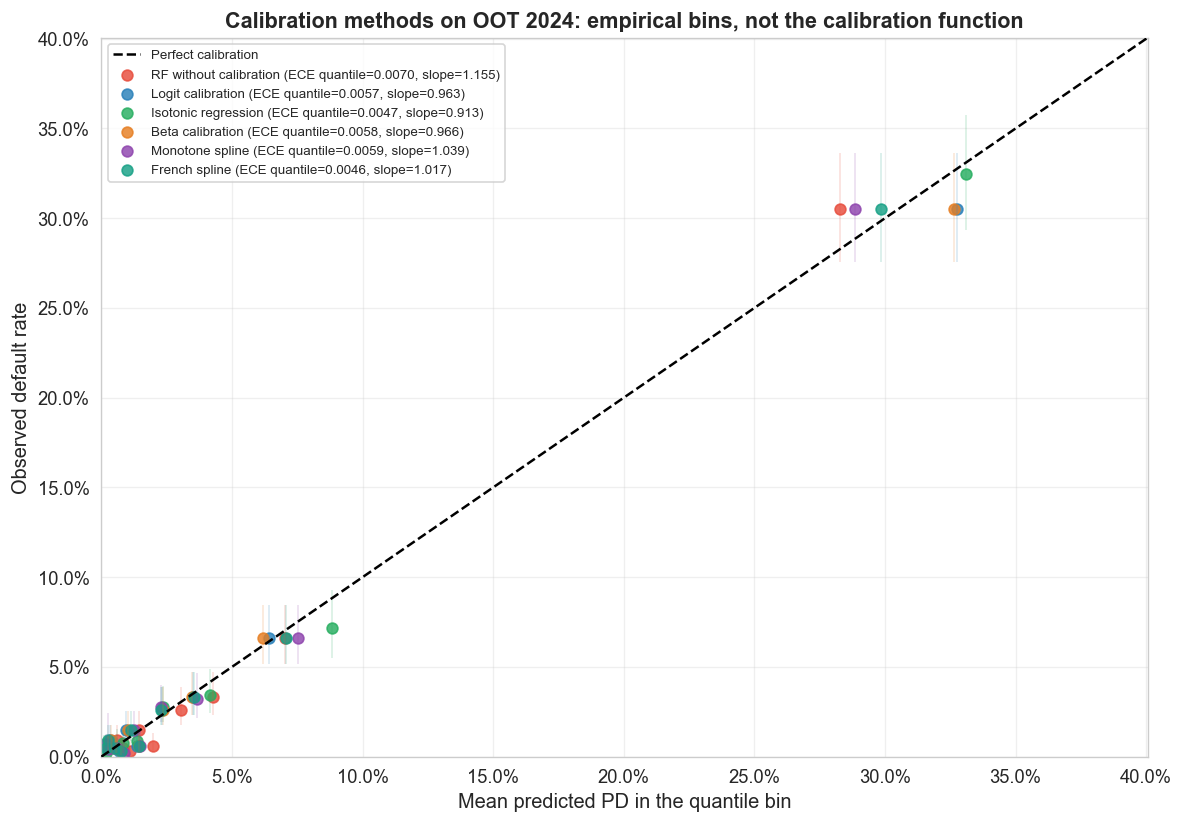

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))

max_axis = 0.0
for table in reliability_tables.values():
    max_axis = max(max_axis, float(table["mean_pred"].max()), float(table["ci_upper"].max()))
max_axis = min(1.0, max(0.10, max_axis * 1.12))

ax.plot([0, max_axis], [0, max_axis], "k--", lw=1.5, label="Perfect calibration", zorder=5)

for i, (name, table) in enumerate(reliability_tables.items()):
    m = summary_metrics(y_test.values, all_methods[name])
    color = COLORS[i % len(COLORS)]
    label = f"{name} (ECE quantile={m['ece_quantile']:.4f}, slope={m['cal_slope']:.3f})"
    ax.scatter(
        table["mean_pred"],
        table["observed_default_rate"],
        color=color,
        s=42,
        alpha=0.82,
        label=label,
    )
    ax.vlines(
        table["mean_pred"],
        table["ci_lower"],
        table["ci_upper"],
        color=color,
        alpha=0.18,
        linewidth=1.0,
    )

ax.set_xlim(0, max_axis)
ax.set_ylim(0, max_axis)
ax.set_xlabel("Mean predicted PD in the quantile bin", fontsize=12)
ax.set_ylabel("Observed default rate", fontsize=12)
ax.set_title("Calibration methods on OOT 2024: empirical bins, not the calibration function", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Backtesting Expected Defaults on the OOT Portfolio

After checking calibration-function shapes and reliability charts, the simplest portfolio backtest is to compare how many defaults actually occurred on OOT versus how many defaults each PD scale expected. This section compares uncalibrated RF with calibrated methods, but RF is interpreted only as a raw score source.


Simple expected-default backtesting on OOT 2024:
Observed number of defaults: 415
Closest to observed defaults by expected defaults: French spline (gap 2.53).


,n_obs,defaults,expected_defaults,default_gap,abs_default_gap,calibration_ratio,actual_default_rate,predicted_default_rate,avg_pd,relative_default_gap_pct
method,,,,,,,,,,
French spline,8776,415,412.47,2.53,2.53,1.01,4.73%,4.70%,4.70%,0.61%
Monotone spline,8776,415,409.72,5.28,5.28,1.01,4.73%,4.67%,4.67%,1.27%
RF without calibration,8776,415,430.25,-15.25,15.25,0.96,4.73%,4.90%,4.90%,-3.68%
Beta calibration,8776,415,430.37,-15.37,15.37,0.96,4.73%,4.90%,4.90%,-3.70%
Logit calibration,8776,415,430.96,-15.96,15.96,0.96,4.73%,4.91%,4.91%,-3.85%
Isotonic regression,8776,415,431.23,-16.23,16.23,0.96,4.73%,4.91%,4.91%,-3.91%


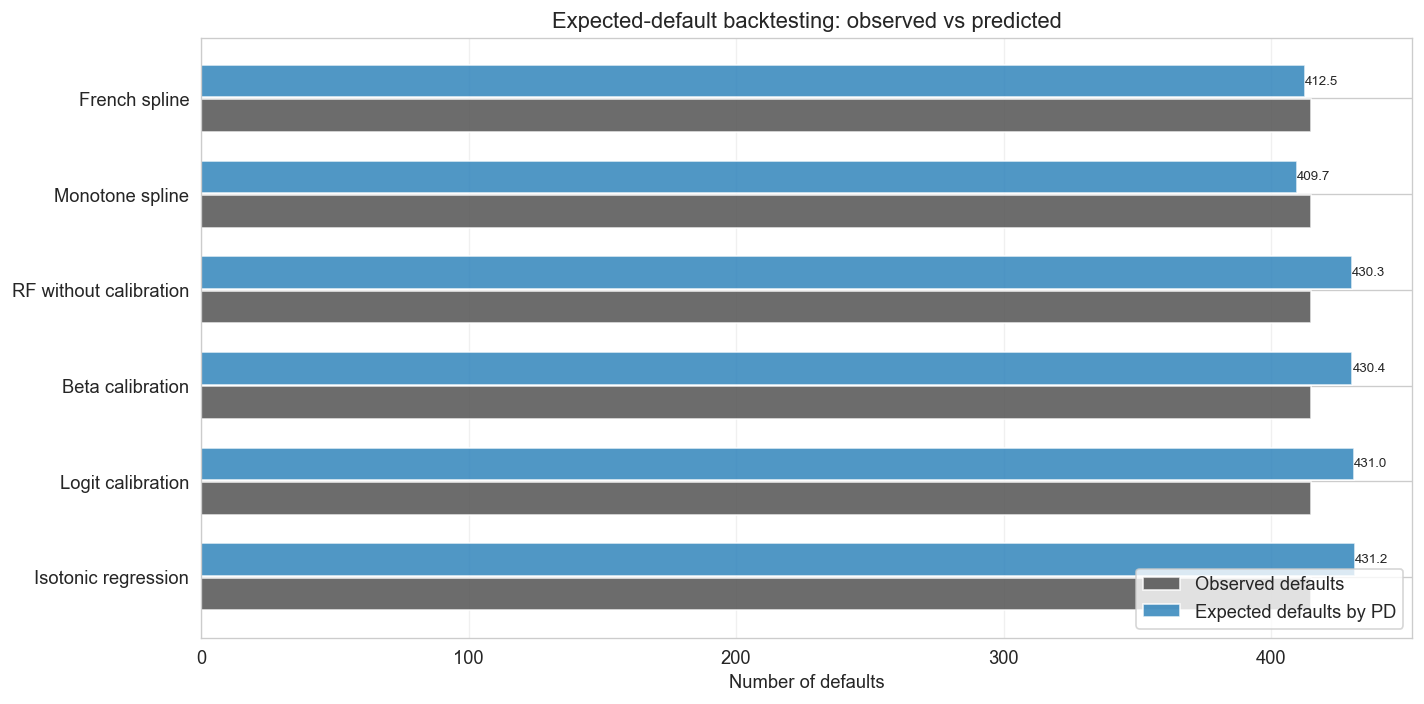

Interpretation: calibration_ratio near 1 means the method matches the overall portfolio default level. It does not replace reliability charts: a method can match the total number of defaults while allocating risk less well across borrower groups.


In [18]:
method_summary = method_portfolio_summary(
    raw_score_frame,
    all_preds,
    default_col="default",
)

backtest_table = method_summary[[
    "n_obs",
    "avg_pd",
    "defaults",
    "expected_defaults",
    "default_gap",
    "calibration_ratio",
]].copy()
backtest_table["actual_default_rate"] = backtest_table["defaults"] / backtest_table["n_obs"]
backtest_table["predicted_default_rate"] = (
    backtest_table["expected_defaults"] / backtest_table["n_obs"]
)
backtest_table["abs_default_gap"] = backtest_table["default_gap"].abs()
backtest_table["relative_default_gap_pct"] = np.where(
    backtest_table["defaults"] > 0,
    backtest_table["default_gap"] / backtest_table["defaults"],
    np.nan,
)
backtest_table = backtest_table[[
    "n_obs",
    "defaults",
    "expected_defaults",
    "default_gap",
    "abs_default_gap",
    "calibration_ratio",
    "actual_default_rate",
    "predicted_default_rate",
    "avg_pd",
    "relative_default_gap_pct",
]]

best_backtest = backtest_table["abs_default_gap"].idxmin()
actual_defaults = float(backtest_table["defaults"].iloc[0])

print("Simple expected-default backtesting on OOT 2024:")
print(f"Observed number of defaults: {actual_defaults:.0f}")
print(
    f"Closest to observed defaults by expected defaults: {best_backtest} "
    f"(gap {backtest_table.loc[best_backtest, 'default_gap']:.2f})."
)

display(
    backtest_table
    .sort_values("abs_default_gap")
    .style.format({
        "avg_pd": "{:.2%}",
        "defaults": "{:.0f}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "abs_default_gap": "{:.2f}",
        "calibration_ratio": "{:.2f}",
        "actual_default_rate": "{:.2%}",
        "predicted_default_rate": "{:.2%}",
        "relative_default_gap_pct": "{:.2%}",
    })
)

plot_backtest = (
    backtest_table
    .reset_index(names="method")
    .sort_values("abs_default_gap", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(plot_backtest))
ax.barh(
    y_pos - 0.18,
    plot_backtest["defaults"],
    height=0.34,
    color="#4c4c4c",
    alpha=0.82,
    label="Observed defaults",
)
ax.barh(
    y_pos + 0.18,
    plot_backtest["expected_defaults"],
    height=0.34,
    color="#2980b9",
    alpha=0.82,
    label="Expected defaults by PD",
)
for i, row in plot_backtest.iterrows():
    ax.text(
        row["expected_defaults"],
        y_pos[list(plot_backtest.index).index(i)] + 0.18,
        f'{row["expected_defaults"]:.1f}',
        va="center",
        ha="left",
        fontsize=8,
    )
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_backtest["method"])
ax.set_xlabel("Number of defaults")
ax.set_title("Expected-default backtesting: observed vs predicted")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.28)
plt.tight_layout()
plt.show()

print(
    "Interpretation: calibration_ratio near 1 means the method matches the overall portfolio "
    "default level. It does not replace reliability charts: a method can match "
    "the total number of defaults while allocating risk less well across borrower groups."
)


### 7.1. Z-stat by Calibration Bins

This block formalizes what reliability charts show visually: in each quantile PD bin, the observed default rate is compared with the expected average PD. Because default is binary, the diagnostic uses a binomial z-stat rather than a classical t-test. Positive `z_stat` means the bin has more observed defaults than expected; negative `z_stat` means fewer defaults than expected. `p_value_binomial` is kept as an exact small-sample reference.


In [19]:
from scipy.stats import binomtest


def add_binomial_calibration_stats(
    table,
    n_col="n_assets",
    defaults_col="defaults",
    pd_col="mean_pred",
    observed_rate_col="observed_default_rate",
):
    out = table.copy()
    n = out[n_col].astype(float)
    defaults = out[defaults_col].astype(float)
    p_expected = np.clip(out[pd_col].astype(float), 1e-12, 1 - 1e-12)

    if observed_rate_col in out.columns:
        observed_rate = out[observed_rate_col].astype(float)
    else:
        observed_rate = np.where(n > 0, defaults / n, np.nan)
        out[observed_rate_col] = observed_rate

    se = np.sqrt(p_expected * (1.0 - p_expected) / n)
    valid = (n > 0) & np.isfinite(se) & (se > 0)

    out["expected_defaults"] = n * p_expected
    out["default_gap"] = defaults - out["expected_defaults"]
    out["dr_minus_pd"] = observed_rate - p_expected
    out["z_stat"] = np.where(valid, out["dr_minus_pd"] / se, np.nan)
    out["p_value_normal"] = np.where(
        valid,
        2.0 * (1.0 - norm.cdf(np.abs(out["z_stat"]))),
        np.nan,
    )
    out["p_value_binomial"] = [
        binomtest(int(round(k)), int(round(n_i)), float(p_i)).pvalue
        if n_i > 0
        else np.nan
        for k, n_i, p_i in zip(defaults, n, p_expected)
    ]
    out["significant_5pct"] = out["p_value_binomial"] < 0.05
    out["direction"] = np.select(
        [out["z_stat"] > 0, out["z_stat"] < 0],
        ["underprediction", "overprediction"],
        default="in line",
    )
    return out


binomial_ztest_tables = []
for method, table in reliability_tables.items():
    method_table = table.copy()
    method_table["bin_id"] = np.arange(1, len(method_table) + 1)
    method_table = add_binomial_calibration_stats(
        method_table,
        n_col="n_assets",
        defaults_col="defaults",
        pd_col="mean_pred",
        observed_rate_col="observed_default_rate",
    )
    method_table.insert(0, "method", method)
    binomial_ztest_tables.append(method_table)

binomial_ztest_table = pd.concat(binomial_ztest_tables, ignore_index=True)
binomial_ztest_summary = (
    binomial_ztest_table
    .groupby("method", sort=False)
    .agg(
        n_bins=("bin_id", "size"),
        significant_bins_5pct=("significant_5pct", "sum"),
        max_abs_z=("z_stat", lambda s: np.nanmax(np.abs(s))),
        min_binomial_p_value=("p_value_binomial", "min"),
        mean_abs_dr_minus_pd=("dr_minus_pd", lambda s: np.nanmean(np.abs(s))),
    )
)

print("Bucket-level binomial calibration test: quantile PD bins")
display(
    binomial_ztest_summary.style.format({
        "significant_bins_5pct": "{:.0f}",
        "max_abs_z": "{:.2f}",
        "min_binomial_p_value": "{:.4f}",
        "mean_abs_dr_minus_pd": "{:.2%}",
    })
)

display_cols = [
    "method",
    "bin_id",
    "n_assets",
    "mean_pred",
    "observed_default_rate",
    "defaults",
    "expected_defaults",
    "default_gap",
    "z_stat",
    "p_value_binomial",
    "significant_5pct",
    "direction",
]
print("Detailed z-stat by quantile bin")
display(
    binomial_ztest_table[display_cols]
    .style.format({
        "mean_pred": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "defaults": "{:.0f}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "z_stat": "{:.2f}",
        "p_value_binomial": "{:.4f}",
    })
)


Bucket-level binomial calibration test: quantile PD bins


,n_bins,significant_bins_5pct,max_abs_z,min_binomial_p_value,mean_abs_dr_minus_pd
method,,,,,
RF without calibration,10,2,2.99,0.0009,0.70%
Logit calibration,10,2,3.03,0.0092,0.55%
Isotonic regression,9,1,8.17,0.0000,0.51%
Beta calibration,10,2,2.63,0.0183,0.56%
Monotone spline,10,2,4.94,0.0002,0.62%
French spline,10,2,3.79,0.0024,0.43%


Detailed z-stat by quantile bin


,method,bin_id,n_assets,mean_pred,observed_default_rate,defaults,expected_defaults,default_gap,z_stat,p_value_binomial,significant_5pct,direction
0,RF without calibration,1,878,0.41%,0.46%,4,3.63,0.37,0.19,0.7884,False,underprediction
1,RF without calibration,2,878,0.60%,0.91%,8,5.24,2.76,1.21,0.2642,False,underprediction
2,RF without calibration,3,877,0.85%,0.46%,4,7.42,-3.42,-1.26,0.2670,False,overprediction
3,RF without calibration,4,878,1.11%,0.34%,3,9.78,-6.78,-2.18,0.0230,True,overprediction
4,RF without calibration,5,877,1.45%,1.48%,13,12.75,0.25,0.07,0.8875,False,underprediction
5,RF without calibration,6,878,1.97%,0.57%,5,17.31,-12.31,-2.99,0.0009,True,overprediction
6,RF without calibration,7,877,3.05%,2.62%,23,26.72,-3.72,-0.73,0.5547,False,overprediction
7,RF without calibration,8,878,4.28%,3.30%,29,37.60,-8.60,-1.43,0.1813,False,overprediction
8,RF without calibration,9,877,7.01%,6.61%,58,61.50,-3.50,-0.46,0.6917,False,overprediction
9,RF without calibration,10,878,28.28%,30.52%,268,248.30,19.70,1.48,0.1439,False,underprediction


## 8. Impact of Calibration on Reserves, RWA, and Required Capital

This section translates statistical calibration results into economic quantities: `EL / Reserves`, unexpected-loss capital, RWA, and required capital under an 8% H1.0 capital ratio. It uses the same stress portfolio, the same 2024 OOT sample, and the same calibrated PD methods as the previous sections. RF is not treated as a calibration method here; logit calibration is used as the benchmark.


### 8.1. Individual PD -> EL, RWA, and Capital

The main capital impact is computed at observation level: each OOT borrower receives its own PD from each method. With fixed `EAD`, `LGD`, and `M`, differences in final capital come only from the shape and level of the calibrated PD scale.

The table adds RWA reduction relative to logit calibration. A positive value means lower RWA than the logit benchmark; a negative value means higher RWA.


In [20]:
# =========================
# Individual PD capital impact: calibrated methods only, logit as benchmark
# =========================

LOGIT_BENCHMARK_METHOD = "Logit calibration"
calibrated_method_names = list(calibrated_probs.keys())
if LOGIT_BENCHMARK_METHOD not in calibrated_probs:
    raise KeyError(f"Benchmark method not found: {LOGIT_BENCHMARK_METHOD}")

capital_methods = {name: calibrated_probs[name] for name in calibrated_method_names}

capital_assumptions = IRBAssumptions(
    lgd=0.40,
    maturity_years=2.5,
    ead=ASSET_EAD if "ASSET_EAD" in globals() else 1_000_000.0,
)

df_rwa = compare_irb_capital_by_method(
    capital_methods,
    assumptions=capital_assumptions,
    baseline_method=LOGIT_BENCHMARK_METHOD,
)

base_required_capital_logit = df_rwa.loc[LOGIT_BENCHMARK_METHOD, "total_required_capital"]
df_rwa["h1_0_if_keep_logit_capital"] = base_required_capital_logit / df_rwa["total_rwa"]
df_rwa["h1_0_uplift_vs_norm"] = (
    df_rwa["h1_0_if_keep_logit_capital"] - capital_assumptions.capital_ratio
)

if "backtest_table" in globals():
    backtesting_source = backtest_table.copy()
elif "method_summary" in globals():
    backtesting_source = method_summary.copy()
    if "abs_default_gap" not in backtesting_source.columns and "default_gap" in backtesting_source.columns:
        backtesting_source["abs_default_gap"] = backtesting_source["default_gap"].abs()
    if {"defaults", "n_obs"}.issubset(backtesting_source.columns):
        backtesting_source["actual_default_rate"] = backtesting_source["defaults"] / backtesting_source["n_obs"]
    if {"expected_defaults", "n_obs"}.issubset(backtesting_source.columns):
        backtesting_source["predicted_default_rate"] = backtesting_source["expected_defaults"] / backtesting_source["n_obs"]
else:
    backtesting_source = None

if backtesting_source is not None:
    backtesting_cols = [
        "expected_defaults",
        "default_gap",
        "abs_default_gap",
        "calibration_ratio",
        "actual_default_rate",
        "predicted_default_rate",
    ]
    backtesting_cols = [col for col in backtesting_cols if col in backtesting_source.columns]
    df_capital_context = df_rwa.join(backtesting_source[backtesting_cols], how="left")
else:
    df_capital_context = df_rwa.copy()

df_capital_context = df_capital_context.sort_values(
    ["total_required_capital", "total_rwa"],
    ascending=True,
)

print(f"OOT portfolio size: {len(y_test):,} assets")
print(f"Observed OOT default rate: {y_test.mean():.2%}")
print(f"EAD per asset: {capital_assumptions.ead:,.0f}")
print(
    f"LGD: {capital_assumptions.lgd:.0%} | "
    f"M: {capital_assumptions.maturity_years:.1f} | "
    f"H1.0 norm: {capital_assumptions.capital_ratio:.0%}"
)
print()
print("Formula map:")
print("  EL / Reserves = PD × LGD × EAD")
print("  UL capital = Basel-style K × EAD")
print("  RWA = UL capital / 8%")
print("  Required capital = 8% × RWA = UL capital")
print("  H1.0 at logit capital = logit required capital / method RWA")

capital_display_cols = [
    "avg_pd",
    "expected_defaults",
    "default_gap",
    "abs_default_gap",
    "calibration_ratio",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_el_plus_ul_capital",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    "h1_0_if_keep_logit_capital",
    "h1_0_uplift_vs_norm",
]
capital_display_cols = [col for col in capital_display_cols if col in df_capital_context.columns]

display(
    df_capital_context[capital_display_cols]
    .rename(columns={
        "avg_pd": "Mean PD",
        "expected_defaults": "Expected defaults",
        "default_gap": "Observed - expected",
        "abs_default_gap": "|gap defaults|",
        "calibration_ratio": "Observed / expected",
        "total_expected_loss": "EL / Reserves",
        "total_unexpected_loss_capital": "UL capital",
        "total_el_plus_ul_capital": "EL + UL capital",
        "total_rwa": "RWA",
        "total_required_capital": "Required capital",
        "rwa_saving_vs_baseline_pct": "RWA reduction vs logit",
        "h1_0_if_keep_logit_capital": "H1.0 with logit capital",
        "h1_0_uplift_vs_norm": "H1.0 uplift vs 8%",
    })
    .style.format({
        "Mean PD": "{:.2%}",
        "Expected defaults": "{:.2f}",
        "Observed - expected": "{:.2f}",
        "|gap defaults|": "{:.2f}",
        "Observed / expected": "{:.2f}",
        "EL / Reserves": "{:,.0f}",
        "UL capital": "{:,.0f}",
        "EL + UL capital": "{:,.0f}",
        "RWA": "{:,.0f}",
        "Required capital": "{:,.0f}",
        "RWA reduction vs logit": "{:.2%}",
        "H1.0 with logit capital": "{:.2%}",
        "H1.0 uplift vs 8%": "{:.2%}",
    })
)


OOT portfolio size: 8,776 assets
Observed OOT default rate: 4.73%
EAD per asset: 1,000,000
LGD: 40% | M: 2.5 | H1.0 norm: 8%

Formula map:
  EL / Reserves = PD × LGD × EAD
  UL capital = Basel-style K × EAD
  RWA = UL capital / 8%
  Required capital = 8% × RWA = UL capital
  H1.0 at logit capital = logit required capital / method RWA


,Mean PD,Expected defaults,Observed - expected,|gap defaults|,Observed / expected,EL / Reserves,UL capital,EL + UL capital,RWA,Required capital,RWA reduction vs logit,H1.0 with logit capital,H1.0 uplift vs 8%
method,,,,,,,,,,,,,
Isotonic regression,4.91%,431.23,-16.23,16.23,0.96,"172,517,258","654,215,002","826,732,259","8,177,687,519","654,215,002",3.62%,8.30%,0.30%
Logit calibration,4.91%,430.96,-15.96,15.96,0.96,"172,383,350","678,772,943","851,156,293","8,484,661,793","678,772,943",0.00%,8.00%,-0.00%
French spline,4.70%,412.47,2.53,2.53,1.01,"164,988,119","686,128,323","851,116,443","8,576,604,041","686,128,323",-1.08%,7.91%,-0.09%
Beta calibration,4.90%,430.37,-15.37,15.37,0.96,"172,148,050","686,304,767","858,452,816","8,578,809,582","686,304,767",-1.11%,7.91%,-0.09%
Monotone spline,4.67%,409.72,5.28,5.28,1.01,"163,889,841","689,353,710","853,243,551","8,616,921,373","689,353,710",-1.56%,7.88%,-0.12%


This table should be read in two directions. Logit calibration is the benchmark because it is simple and easy to explain. Positive RWA reduction shows how much the method reduces capital load versus logit; a negative value means the method requires more RWA. That result should not be automatically treated as better or worse without checking expected defaults and the reliability picture.


### 8.2. Rating Master Scale with Target CT

This block answers a different question: what PD curve appears across the `A1 ... E` rating scale if each method keeps the same OOT borrower distribution by master rating and then shifts rating PDs so that the weighted average PD matches the target central tendency. This is a portfolio-level rating view, not an individual-borrower PD assignment.


In [21]:
TARGET_CT = float(y_calib.mean())
ASSET_EAD = capital_assumptions.ead

df_calib_master = df.loc[y_calib.index].copy()
df_test_master = df.loc[y_test.index].copy()
df_calib_master["master_rating"] = assign_master_scale_ratings(
    scores_calib,
    reference_scores=scores_calib,
)
df_test_master["master_rating"] = assign_master_scale_ratings(
    scores_test,
    reference_scores=scores_calib,
)

master_scale_panel = compare_methods_by_rating_master_scale(
    df_test_master,
    capital_methods,
    score_values=scores_test,
    target_pd=TARGET_CT,
    default_asset_ead=ASSET_EAD,
)
master_scale_summary = summarize_rating_scale(master_scale_panel, method_col="method")
master_scale_structure_check = validate_common_rating_structure(master_scale_panel)

master_scale_capital = rating_scale_capital(
    master_scale_panel,
    assumptions=capital_assumptions,
    method_col="method",
)

rating_pd_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="pd_rating")
    .loc[list(MASTER_SCALE_RATINGS)]
)

print(f"Target CT from train+calibration: {TARGET_CT:.2%}")
print(f"OOT default rate:                {y_test.mean():.2%}")
print(f"Expected defaults at target CT:  {len(y_test) * TARGET_CT:.2f}")

print("Rating PD curve after target-CT shift")
display(rating_pd_matrix.style.format("{:.2%}"))

print("Master-scale summary: same borrowers per rating, method-specific PD curve")
display(
    master_scale_summary[[
        "n_assets",
        "target_weighted_pd",
        "defaults",
        "expected_defaults",
        "pd_min",
        "pd_max",
    ]]
    .style.format({
        "target_weighted_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "pd_min": "{:.2%}",
        "pd_max": "{:.2%}",
    })
)


Target CT from train+calibration: 4.81%
OOT default rate:                4.73%
Expected defaults at target CT:  421.88
Rating PD curve after target-CT shift


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline
rating,,,,,
A1,0.23%,0.17%,0.04%,0.19%,0.15%
A2,0.30%,0.24%,0.12%,0.26%,0.22%
A3,0.42%,0.32%,0.14%,0.37%,0.29%
B1,0.56%,0.57%,0.45%,0.50%,0.62%
B2,0.70%,0.76%,0.71%,0.64%,0.84%
B3,0.87%,0.99%,0.94%,0.82%,1.10%
C1,1.11%,1.29%,1.32%,1.05%,1.43%
C2,1.51%,1.57%,1.41%,1.46%,1.62%
C3,2.27%,2.33%,2.21%,2.25%,2.31%


Master-scale summary: same borrowers per rating, method-specific PD curve


,n_assets,target_weighted_pd,defaults,expected_defaults,pd_min,pd_max
method,,,,,,
Beta calibration,8776,4.81%,415.000000,421.88,0.23%,36.66%
French spline,8776,4.81%,415.000000,421.88,0.17%,34.40%
Isotonic regression,8776,4.81%,415.000000,421.88,0.04%,35.40%
Logit calibration,8776,4.81%,415.000000,421.88,0.19%,36.61%
Monotone spline,8776,4.81%,415.000000,421.88,0.15%,33.44%


### 8.3. Fixed Master-Scale Buckets

Now an external set of PD boundaries `A1 ... E` is used. Each individual PD falls directly into a fixed rating bucket. Bucket composition may therefore differ by method: calibration changes the PDs, so some borrowers move between rating ranges. This view is closer to a rating-system implementation question.


In [22]:
fixed_scale_bounds = master_scale_bounds_table()
fixed_master_scale_panel = method_master_scale_distribution(
    df_test_master,
    capital_methods,
    default_asset_ead=ASSET_EAD,
)

fixed_master_scale_rwa_by_rating = rating_scale_capital_by_rating(
    fixed_master_scale_panel,
    assumptions=capital_assumptions,
    method_col="method",
    rating_col="rating",
    pd_col="pd_rating",
)

fixed_master_scale_rwa_summary = (
    fixed_master_scale_rwa_by_rating
    .groupby("method", sort=False)
    .agg(
        total_ead=("total_ead", "sum"),
        total_expected_loss=("total_expected_loss", "sum"),
        total_unexpected_loss_capital=("total_unexpected_loss_capital", "sum"),
        total_el_plus_ul_capital=("total_el_plus_ul_capital", "sum"),
        total_rwa=("total_rwa", "sum"),
        total_required_capital=("total_required_capital", "sum"),
    )
)
fixed_master_scale_rwa_summary["rwa_rate_to_ead"] = (
    fixed_master_scale_rwa_summary["total_rwa"]
    / fixed_master_scale_rwa_summary["total_ead"]
)
if LOGIT_BENCHMARK_METHOD not in fixed_master_scale_rwa_summary.index:
    raise KeyError(f"Benchmark method not found in fixed master-scale summary: {LOGIT_BENCHMARK_METHOD}")
fixed_logit_rwa = fixed_master_scale_rwa_summary.loc[LOGIT_BENCHMARK_METHOD, "total_rwa"]
fixed_master_scale_rwa_summary["rwa_saving_vs_logit"] = (
    fixed_logit_rwa - fixed_master_scale_rwa_summary["total_rwa"]
)
fixed_master_scale_rwa_summary["rwa_saving_vs_logit_pct"] = (
    fixed_master_scale_rwa_summary["rwa_saving_vs_logit"] / fixed_logit_rwa
)

fixed_master_scale_counts = (
    fixed_master_scale_panel
    .pivot(index="rating", columns="method", values="n_assets")
    .reindex(MASTER_SCALE_RATINGS)
)
synthetic_oot_rating_counts = (
    df_test_master.groupby("rating", observed=False)
    .agg(n_assets=("default", "size"), defaults=("default", "sum"), bad_rate=("default", "mean"))
    .reindex(["A", "B", "C", "D", "E"])
)
synthetic_oot_rating_counts["asset_share"] = synthetic_oot_rating_counts["n_assets"] / len(df_test_master)

fixed_axis_check = (
    fixed_master_scale_panel
    .groupby("method", sort=False)
    .agg(
        first_rating=("rating", "first"),
        n_rating_rows=("rating", "size"),
        total_assets=("n_assets", "sum"),
        total_ead=("total_ead", "sum"),
    )
)
fixed_axis_check["starts_with_a1"] = fixed_axis_check["first_rating"].eq("A1")
fixed_axis_check["has_full_axis"] = fixed_axis_check["n_rating_rows"].eq(len(MASTER_SCALE_RATINGS))
fixed_axis_check["same_total_assets"] = fixed_axis_check["total_assets"].eq(len(df_test_master))
fixed_axis_check["same_total_ead"] = fixed_axis_check["total_ead"].eq(len(df_test_master) * ASSET_EAD)

if not fixed_axis_check[["starts_with_a1", "has_full_axis", "same_total_assets", "same_total_ead"]].all().all():
    raise ValueError("Fixed master-scale tables are not synchronized across methods.")

print("Fixed PD master-scale boundaries")
display(
    fixed_scale_bounds.set_index("rating").style.format({
        "pd_lower": "{:.2%}",
        "pd_upper": "{:.2%}",
        "pd_avg_master": "{:.2%}",
    })
)

print("Original synthetic OOT source rating mix")
display(
    synthetic_oot_rating_counts.style.format({
        "asset_share": "{:.1%}",
        "bad_rate": "{:.2%}",
    })
)

print("Predicted fixed master-scale bucket counts by method")
display(fixed_master_scale_counts.style.format("{:,.0f}"))

print("Fixed master-scale RWA / EL / capital summary")
display(
    fixed_master_scale_rwa_summary.style.format({
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_unexpected_loss_capital": "{:,.0f}",
        "total_el_plus_ul_capital": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "rwa_rate_to_ead": "{:.2%}",
        "rwa_saving_vs_logit": "{:,.0f}",
        "rwa_saving_vs_logit_pct": "{:.2%}",
    })
)

print("Consistency check passed: every method keeps A1...E, starts at A1, and covers the same OOT portfolio/EAD.")


Fixed PD master-scale boundaries


,pd_lower,pd_upper,pd_avg_master
rating,,,
A1,0.00%,0.06%,0.05%
A2,0.06%,0.08%,0.07%
A3,0.08%,0.10%,0.09%
B1,0.10%,0.14%,0.12%
B2,0.14%,0.30%,0.22%
B3,0.30%,0.65%,0.47%
C1,0.65%,1.05%,0.85%
C2,1.05%,1.82%,1.55%
C3,1.82%,2.91%,2.37%


Original synthetic OOT source rating mix


,n_assets,defaults,bad_rate,asset_share
rating,,,,
A,257,0,0.00%,2.9%
B,3134,13,0.41%,35.7%
C,3619,65,1.80%,41.2%
D,1421,156,10.98%,16.2%
E,345,181,52.46%,3.9%


Predicted fixed master-scale bucket counts by method


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline
rating,,,,,
A1,0,0,222,0,0
A2,0,0,424,0,0
A3,0,0,0,0,0
B1,0,0,"1,074",0,460
B2,884,"1,626",478,"1,171","1,227"
B3,"1,781",750,560,"1,739",621
C1,"1,403","1,348","1,056","1,312","1,337"
C2,"1,233","1,547","1,460","1,120","1,590"
C3,848,"1,073","1,086",798,"1,154"


Fixed master-scale RWA / EL / capital summary


,total_ead,total_expected_loss,total_unexpected_loss_capital,total_el_plus_ul_capital,total_rwa,total_required_capital,rwa_rate_to_ead,rwa_saving_vs_logit,rwa_saving_vs_logit_pct
method,,,,,,,,,
Beta calibration,"8,776,000,000","171,038,720","705,361,560","876,400,280","8,817,019,504","705,361,560",100.47%,"-108,724,413",-1.25%
French spline,"8,776,000,000","172,207,860","707,393,172","879,601,032","8,842,414,651","707,393,172",100.76%,"-134,119,560",-1.54%
Isotonic regression,"8,776,000,000","159,983,520","667,954,855","827,938,375","8,349,435,685","667,954,855",95.14%,"358,859,406",4.12%
Logit calibration,"8,776,000,000","173,003,640","696,663,607","869,667,247","8,708,295,091","696,663,607",99.23%,0,0.00%
Monotone spline,"8,776,000,000","170,715,240","706,423,104","877,138,344","8,830,288,798","706,423,104",100.62%,"-121,993,707",-1.40%


Consistency check passed: every method keeps A1...E, starts at A1, and covers the same OOT portfolio/EAD.


### 8.4.1. Z-stat by Fixed Master-Scale Buckets

The same binomial diagnostic is applied not to quantile reliability bins, but to external fixed master-scale buckets `A1 ... E`. For each method, buckets are formed from its calibrated PD, and then the observed default rate inside each bucket is compared with the bucket PD level. This helps identify rating grades where the fixed scale underpredicts or overpredicts defaults.


In [23]:
master_scale_ztest_table = add_binomial_calibration_stats(
    fixed_master_scale_panel,
    n_col="n_assets",
    defaults_col="defaults",
    pd_col="pd_rating",
    observed_rate_col="observed_default_rate",
)

master_scale_ztest_summary = (
    master_scale_ztest_table
    .groupby("method", sort=False)
    .agg(
        n_non_empty_buckets=("n_assets", lambda s: int((s > 0).sum())),
        significant_buckets_5pct=("significant_5pct", "sum"),
        max_abs_z=("z_stat", lambda s: np.nanmax(np.abs(s))),
        min_binomial_p_value=("p_value_binomial", "min"),
        total_default_gap=("default_gap", "sum"),
    )
)

print("Bucket-level binomial calibration test: fixed master-scale A1...E")
display(
    master_scale_ztest_summary.style.format({
        "significant_buckets_5pct": "{:.0f}",
        "max_abs_z": "{:.2f}",
        "min_binomial_p_value": "{:.4f}",
        "total_default_gap": "{:.2f}",
    })
)

master_display_cols = [
    "method",
    "rating",
    "n_assets",
    "pd_rating",
    "observed_default_rate",
    "defaults",
    "expected_defaults",
    "default_gap",
    "z_stat",
    "p_value_binomial",
    "significant_5pct",
    "direction",
]
print("Detailed z-stat by fixed master-scale bucket")
display(
    master_scale_ztest_table[master_display_cols]
    .style.format({
        "pd_rating": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "defaults": "{:.0f}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "z_stat": "{:.2f}",
        "p_value_binomial": "{:.4f}",
    })
)


Bucket-level binomial calibration test: fixed master-scale A1...E


,n_non_empty_buckets,significant_buckets_5pct,max_abs_z,min_binomial_p_value,total_default_gap
method,,,,,
Logit calibration,9,0,1.78,0.0884,-17.51
Isotonic regression,12,2,7.68,0.0000,15.04
Beta calibration,9,0,1.87,0.0640,-12.60
Monotone spline,10,2,4.45,0.0005,-11.79
French spline,9,2,3.93,0.0012,-15.52


Detailed z-stat by fixed master-scale bucket


,method,rating,n_assets,pd_rating,observed_default_rate,defaults,expected_defaults,default_gap,z_stat,p_value_binomial,significant_5pct,direction
0,Logit calibration,A1,0,0.05%,0.00%,0,0.00,0.00,nan,nan,False,in line
1,Logit calibration,A2,0,0.07%,0.00%,0,0.00,0.00,nan,nan,False,in line
2,Logit calibration,A3,0,0.09%,0.00%,0,0.00,0.00,nan,nan,False,in line
3,Logit calibration,B1,0,0.12%,0.00%,0,0.00,0.00,nan,nan,False,in line
4,Logit calibration,B2,1171,0.22%,0.43%,5,2.58,2.42,1.51,0.1190,False,underprediction
5,Logit calibration,B3,1739,0.47%,0.75%,13,8.17,4.83,1.69,0.1094,False,underprediction
6,Logit calibration,C1,1312,0.85%,0.91%,12,11.15,0.85,0.26,0.7622,False,underprediction
7,Logit calibration,C2,1120,1.55%,0.89%,10,17.36,-7.36,-1.78,0.0884,False,overprediction
8,Logit calibration,C3,798,2.37%,2.51%,20,18.87,1.13,0.26,0.7269,False,underprediction
9,Logit calibration,D1,1287,4.05%,3.73%,48,52.12,-4.12,-0.58,0.6205,False,overprediction


### 8.4. Visual Diagnostics of the Fixed Master Scale

The charts below show two different effects: how many borrowers fall into each fixed bucket and which PD/DR levels appear inside those buckets. This helps explain why one method can reduce RWA more than another: the result depends not only on average PD, but also on how borrowers move across the nonlinear IRB capital curve.


Mean calibrated PD inside each fixed bucket


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline
rating,,,,,
A1,,,0.00%,,
A2,,,0.07%,,
A3,,,,,
B1,,,0.12%,,0.14%
B2,0.25%,0.21%,0.19%,0.23%,0.21%
B3,0.46%,0.43%,0.60%,0.47%,0.40%
C1,0.83%,0.78%,0.82%,0.83%,0.82%
C2,1.36%,1.33%,1.36%,1.36%,1.39%
C3,2.38%,2.38%,2.36%,2.38%,2.33%


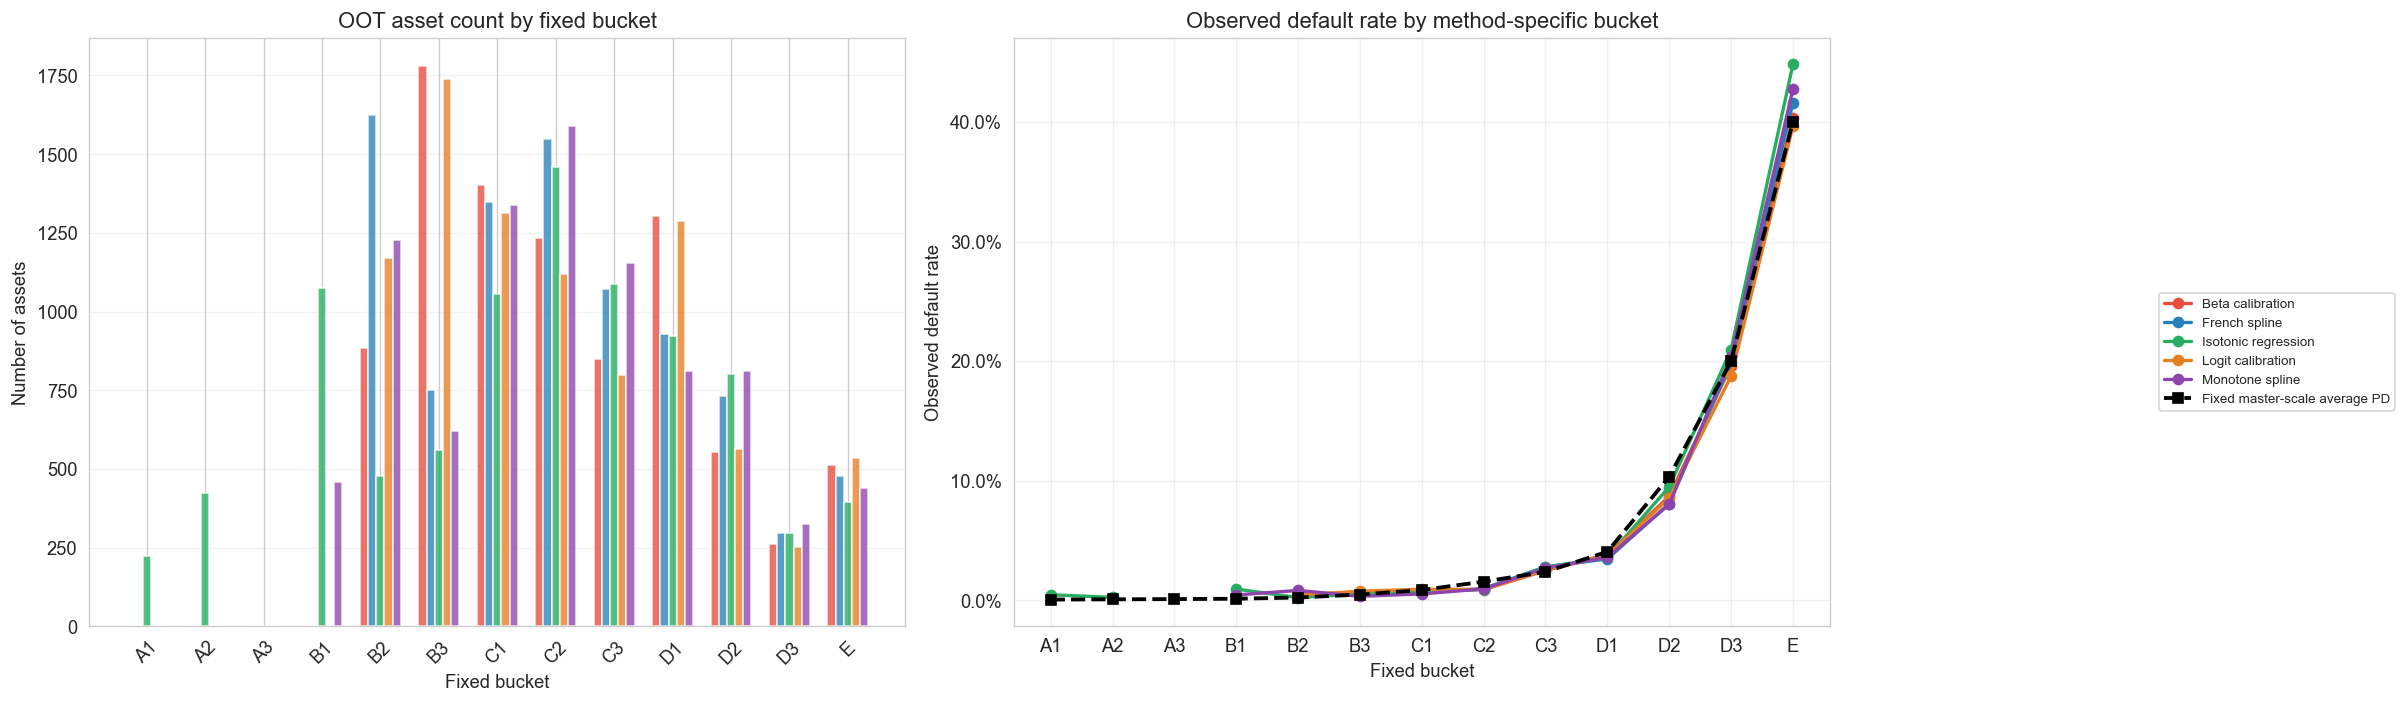

In [24]:
fixed_rating_avg_pd_matrix = (
    fixed_master_scale_panel
    .assign(avg_pd_plot=lambda x: x["avg_pd"].where(x["n_assets"] > 0))
    .pivot(index="rating", columns="method", values="avg_pd_plot")
    .reindex(MASTER_SCALE_RATINGS)
)
fixed_rating_count_matrix = (
    fixed_master_scale_panel
    .pivot(index="rating", columns="method", values="n_assets")
    .reindex(MASTER_SCALE_RATINGS)
)
fixed_rating_observed_dr_matrix = (
    fixed_master_scale_panel
    .assign(observed_dr_plot=lambda x: x["observed_default_rate"].where(x["n_assets"] > 0))
    .pivot(index="rating", columns="method", values="observed_dr_plot")
    .reindex(MASTER_SCALE_RATINGS)
)
ideal_pd_by_rating = fixed_scale_bounds.set_index("rating")["pd_avg_master"].reindex(MASTER_SCALE_RATINGS)

print("Mean calibrated PD inside each fixed bucket")
display(
    fixed_rating_avg_pd_matrix
    .style
    .format("{:.2%}", na_rep="")
    .background_gradient(axis=None, cmap="YlOrRd")
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(MASTER_SCALE_RATINGS))
methods = list(fixed_rating_count_matrix.columns)
bar_width = min(0.8 / max(len(methods), 1), 0.14)
for i, method in enumerate(methods):
    offset = (i - (len(methods) - 1) / 2) * bar_width
    axes[0].bar(
        x + offset,
        fixed_rating_count_matrix[method].fillna(0),
        width=bar_width,
        color=COLORS[i % len(COLORS)],
        alpha=0.78,
        label=method,
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(MASTER_SCALE_RATINGS, rotation=45)
axes[0].set_title("OOT asset count by fixed bucket")
axes[0].set_xlabel("Fixed bucket")
axes[0].set_ylabel("Number of assets")
axes[0].grid(axis="y", alpha=0.25)

for i, method in enumerate(fixed_rating_observed_dr_matrix.columns):
    axes[1].plot(
        fixed_rating_observed_dr_matrix.index,
        fixed_rating_observed_dr_matrix[method],
        marker="o",
        linewidth=2,
        color=COLORS[i % len(COLORS)],
        label=method,
    )
axes[1].plot(
    ideal_pd_by_rating.index,
    ideal_pd_by_rating,
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.3,
    label="Fixed master-scale average PD",
)
axes[1].set_title("Observed default rate by method-specific bucket")
axes[1].set_xlabel("Fixed bucket")
axes[1].set_ylabel("Observed default rate")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].grid(True, alpha=0.3)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()


### 8.5. Illustrative Reserve and Capital Calculation for the Final PD

The table below keeps the mentoring calculation format with `FRAT_FINAL_PD`, `EAD`, `DEFAULT_DURING_NEXT_YEAR`, `Reserves`, `R`, `RWA_capital`, and `Capital_true`. To keep the final PD choice aligned with the earlier analysis, the method is selected from the backtest by minimum absolute expected-default gap.


In [25]:
if "backtest_table" in globals():
    final_method_source = backtest_table
elif "method_summary" in globals():
    final_method_source = method_summary.copy()
    if "abs_default_gap" not in final_method_source.columns and "default_gap" in final_method_source.columns:
        final_method_source["abs_default_gap"] = final_method_source["default_gap"].abs()
else:
    final_method_source = None

if final_method_source is not None and "abs_default_gap" in final_method_source.columns:
    calibrated_method_names = [name for name in calibrated_probs if name in final_method_source.index]
    final_pd_method = (
        final_method_source.loc[calibrated_method_names, "abs_default_gap"].idxmin()
        if calibrated_method_names
        else list(calibrated_probs.keys())[-1]
    )
else:
    final_pd_method = list(calibrated_probs.keys())[-1]

print(f"Final PD for the 845-P calculation: {final_pd_method}")

data_ocp = pd.DataFrame({
    "FRAT_FINAL_PD": np.clip(calibrated_probs[final_pd_method], 1e-6, 1 - 1e-6),
    "EAD": np.full(len(y_test), capital_assumptions.ead, dtype=float),
    "DEFAULT_DURING_NEXT_YEAR": y_test.values.astype(float),
})

data_ocp["Reserves"] = data_ocp.FRAT_FINAL_PD * capital_assumptions.lgd * data_ocp.EAD
data_ocp["R"] = (
    0.12 * ((1 - np.exp(-50 * data_ocp.FRAT_FINAL_PD)) / (1 - np.exp(-50)))
    + 0.24 * (1 - ((1 - np.exp(-50 * data_ocp.FRAT_FINAL_PD)) / (1 - np.exp(-50))))
)
data_ocp["RWA_capital"] = (
    data_ocp.EAD
    * capital_assumptions.lgd
    * (
        norm.cdf(
            (
                norm.ppf(data_ocp.FRAT_FINAL_PD)
                + np.sqrt(data_ocp.R) * norm.ppf(0.999)
            )
            / np.sqrt(1 - data_ocp.R)
        )
        - data_ocp.FRAT_FINAL_PD
    )
    * (1 / (1 - 1.5 * (0.11852 - 0.05478 * np.log(data_ocp.FRAT_FINAL_PD)) ** 2))
)
data_ocp["Capital_true"] = np.where(
    data_ocp.DEFAULT_DURING_NEXT_YEAR == 1.0,
    capital_assumptions.lgd * data_ocp.EAD,
    data_ocp.Reserves + data_ocp.RWA_capital,
)
data_ocp["RWA"] = data_ocp["RWA_capital"] / capital_assumptions.capital_ratio

mentor_summary = pd.Series({
    "avg_pd": data_ocp["FRAT_FINAL_PD"].mean(),
    "expected_defaults": data_ocp["FRAT_FINAL_PD"].sum(),
    "reserves_total": data_ocp["Reserves"].sum(),
    "ul_capital_total": data_ocp["RWA_capital"].sum(),
    "rwa_total": data_ocp["RWA"].sum(),
    "capital_true_total": data_ocp["Capital_true"].sum(),
})

print("Mentor-format totals")
display(mentor_summary.to_frame("value").style.format({"value": "{:,.4f}"}))

display(
    data_ocp.head(3).style.format({
        "FRAT_FINAL_PD": "{:.4%}",
        "EAD": "{:,.0f}",
        "DEFAULT_DURING_NEXT_YEAR": "{:.0f}",
        "Reserves": "{:,.2f}",
        "R": "{:.4f}",
        "RWA_capital": "{:,.2f}",
        "Capital_true": "{:,.2f}",
        "RWA": "{:,.2f}",
    })
)


Final PD for the 845-P calculation: French spline
Mentor-format totals


,value
avg_pd,0.0470
expected_defaults,412.4703
reserves_total,"164,988,119.3647"
ul_capital_total,"686,128,323.2634"
rwa_total,"8,576,604,040.7928"
capital_true_total,"917,345,212.3579"


,FRAT_FINAL_PD,EAD,DEFAULT_DURING_NEXT_YEAR,Reserves,R,RWA_capital,Capital_true,RWA
0,0.2133%,"1,000,000",0,853.01,0.2279,"32,318.98","33,172.00","403,987.27"
1,2.6583%,"1,000,000",0,"10,633.35",0.1518,"88,338.95","98,972.30","1,104,236.88"
2,0.6853%,"1,000,000",0,"2,741.12",0.2052,"56,747.32","59,488.43","709,341.46"


### 8.6. Limitations of the RWA Block

The calculation is intended to assess capital sensitivity to calibrated PD, not to serve as full regulatory reporting.

Key simplifications:

- a Basel-style IRB formula is used for illustration, not a complete production IRB process;
- `EAD`, `LGD`, and `M` are fixed;
- no guarantees are made on regulatory floors, downturn LGD, conservatism margins, or validation overlays;
- the synthetic portfolio is designed to demonstrate methodology rather than reproduce a specific bank.


### 8.7. Visualizing the Effect on RWA and Capital

The charts below show how differences in calibrated PD flow into reserves, RWA, RWA reduction versus logit calibration, and the hypothetical H1.0 ratio when capital sufficient for logit PD is kept unchanged.


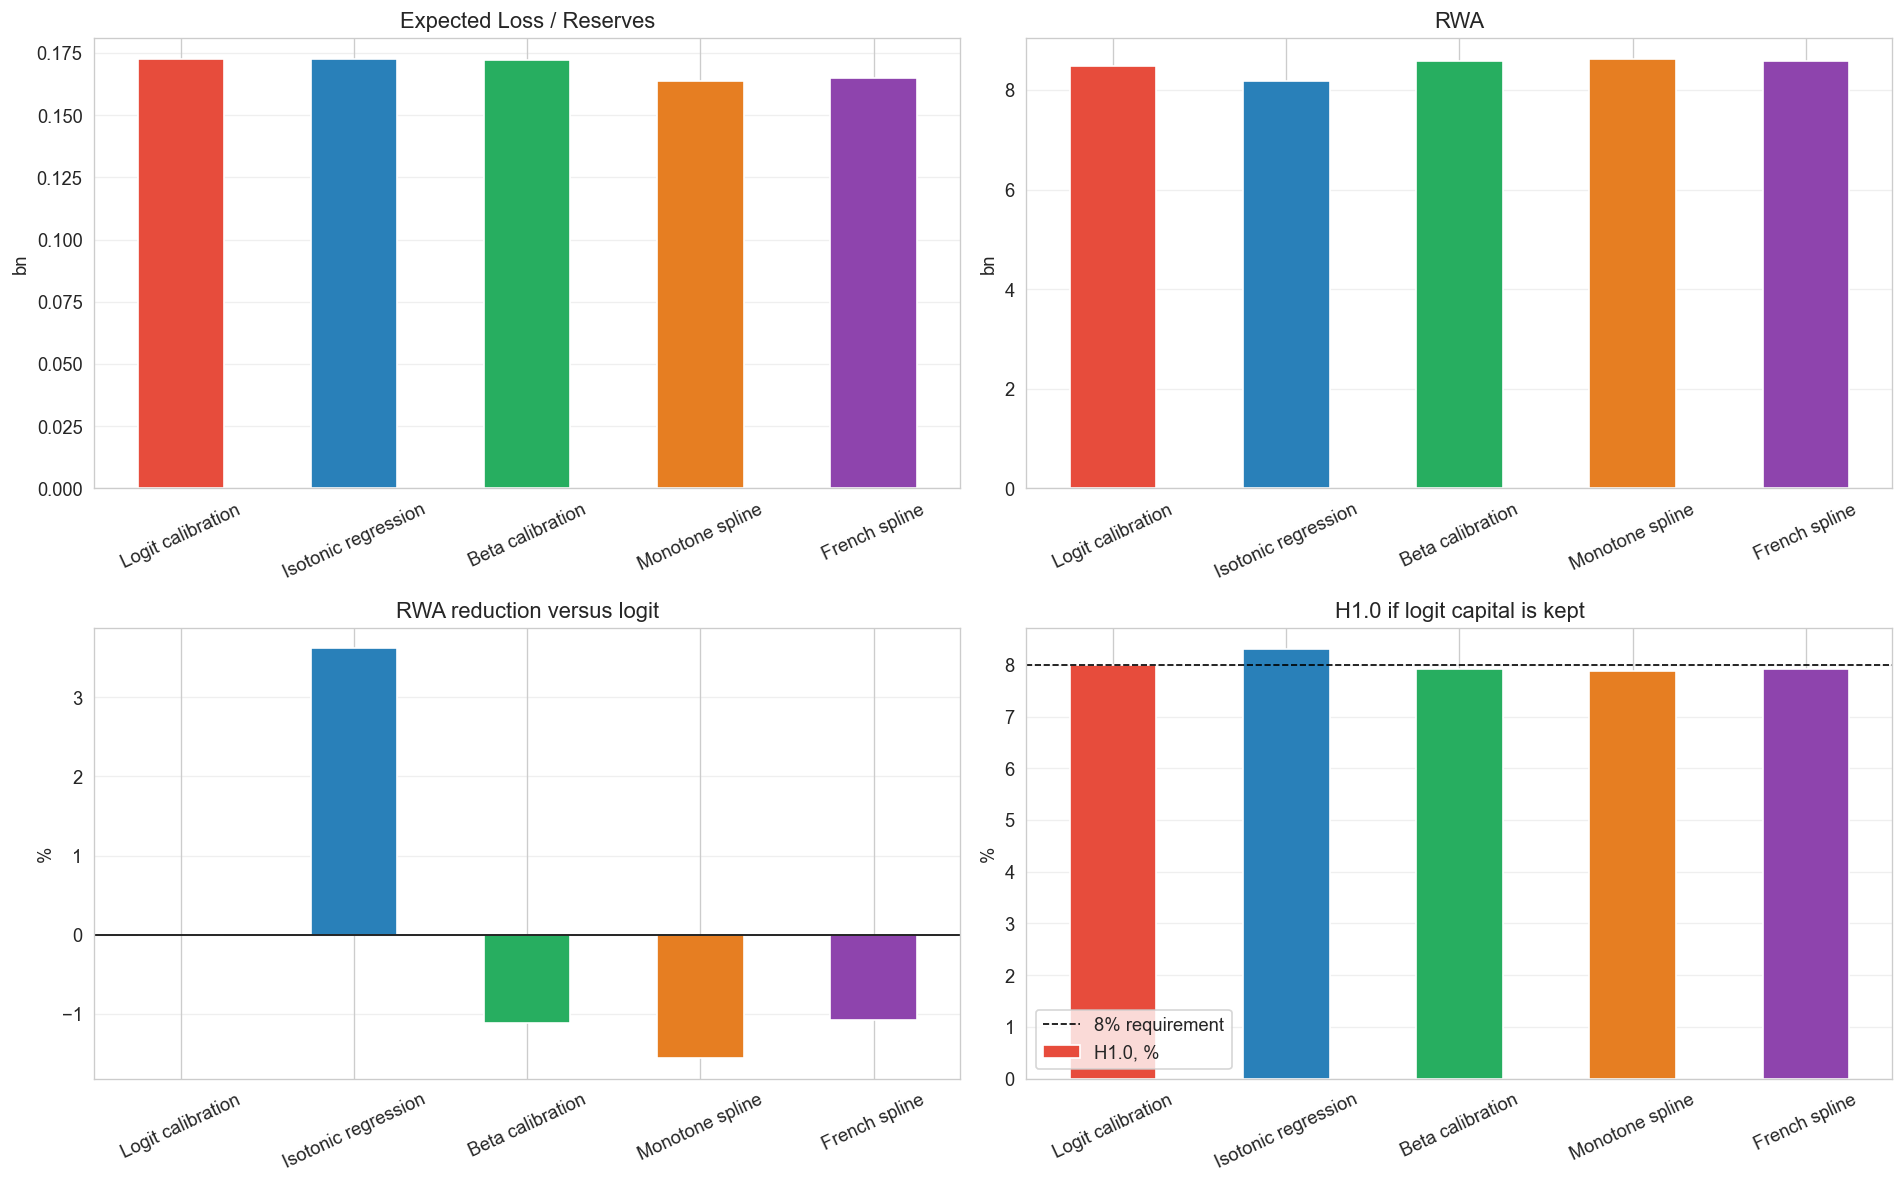

In [26]:
plot_df = df_rwa.reset_index().copy()
plot_df["EL, bn"] = plot_df["total_expected_loss"] / 1_000_000_000
plot_df["RWA, bn"] = plot_df["total_rwa"] / 1_000_000_000
plot_df["RWA reduction vs logit, %"] = 100 * plot_df["rwa_saving_vs_baseline_pct"]
plot_df["H1.0, %"] = 100 * plot_df["h1_0_if_keep_logit_capital"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_specs = [
    ("EL, bn", "Expected Loss / Reserves", "bn"),
    ("RWA, bn", "RWA", "bn"),
    ("RWA reduction vs logit, %", "RWA reduction versus logit", "%"),
    ("H1.0, %", "H1.0 if logit capital is kept", "%"),
]

for ax, (col, title, ylabel) in zip(axes.flatten(), plot_specs):
    plot_df.plot(
        x="method",
        y=col,
        kind="bar",
        ax=ax,
        legend=False,
        rot=25,
        color=COLORS[:len(plot_df)] if len(plot_df) <= len(COLORS) else None,
        title=title,
    )
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 1].axhline(
    100 * capital_assumptions.capital_ratio,
    color="black",
    lw=1,
    linestyle="--",
    label="8% requirement",
)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### 8.8. Concave Total Credit-Risk Capital Function

The nonlinearity of the IRB function means that moving borrowers across PD ranges can change capital non-proportionally to average PD. The chart below builds a smoothed relationship between PD and capital to EAD.

- `K_EL = EL / EAD` is the reserve component;
- `K_UL = unexpected loss capital / EAD` is the IRB capital component;
- `K_TOTAL = K_EL + K_UL` is total credit-risk capital before translating it into RWA.


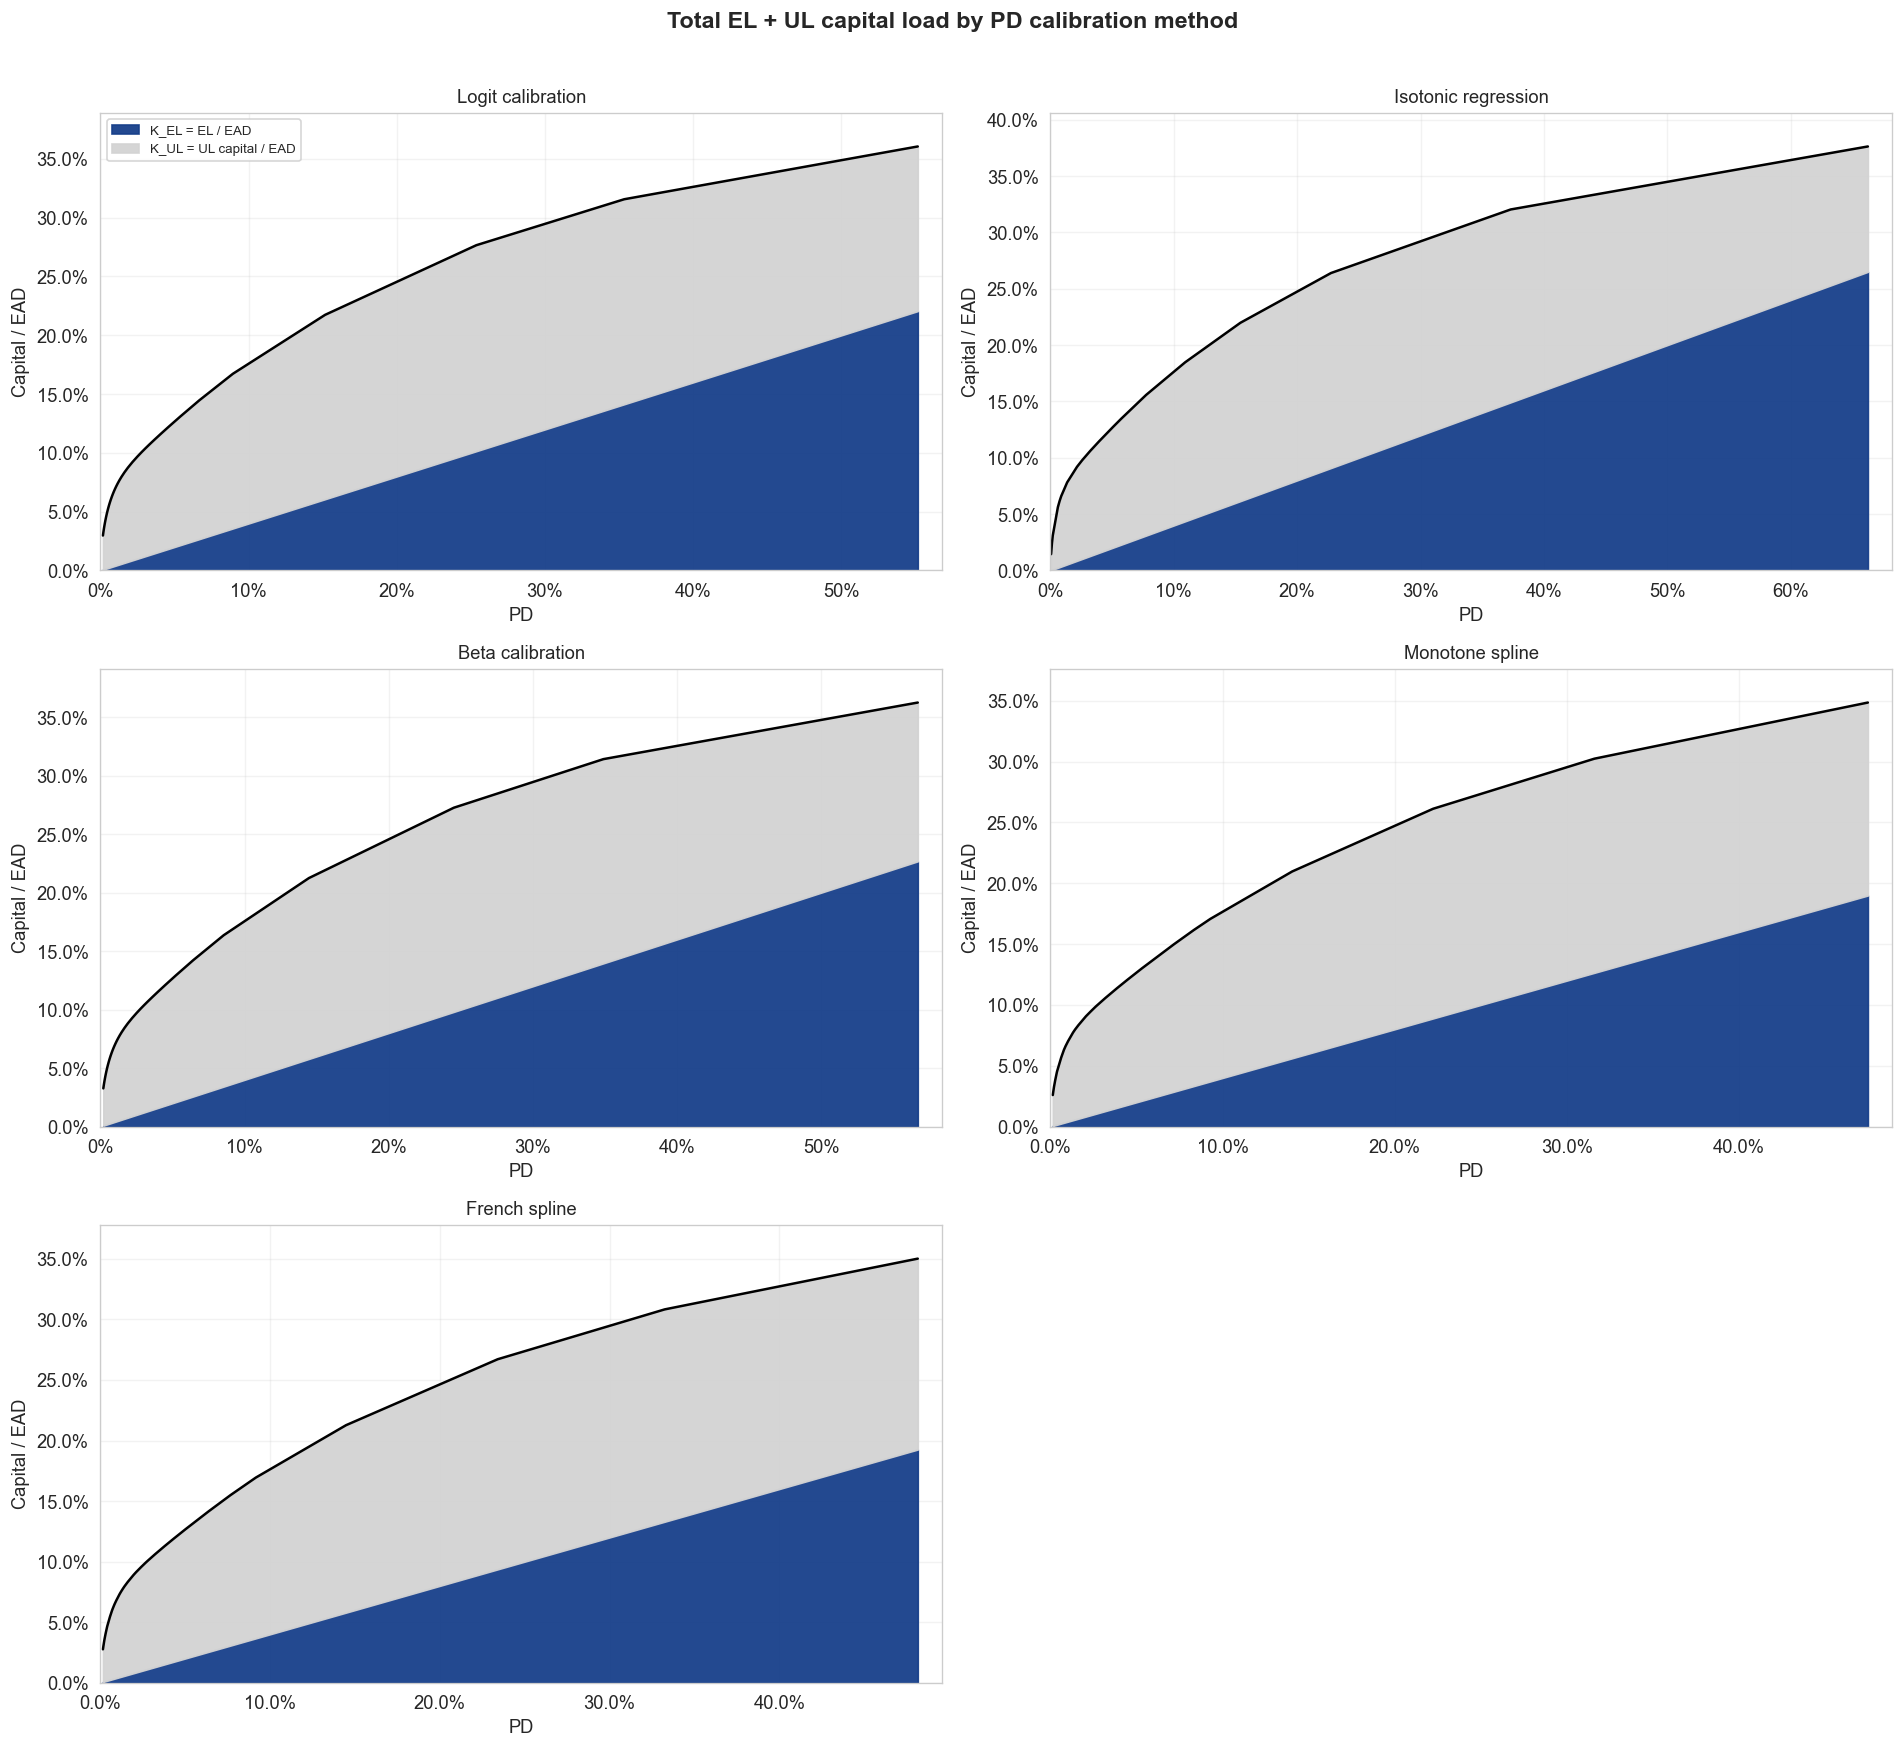

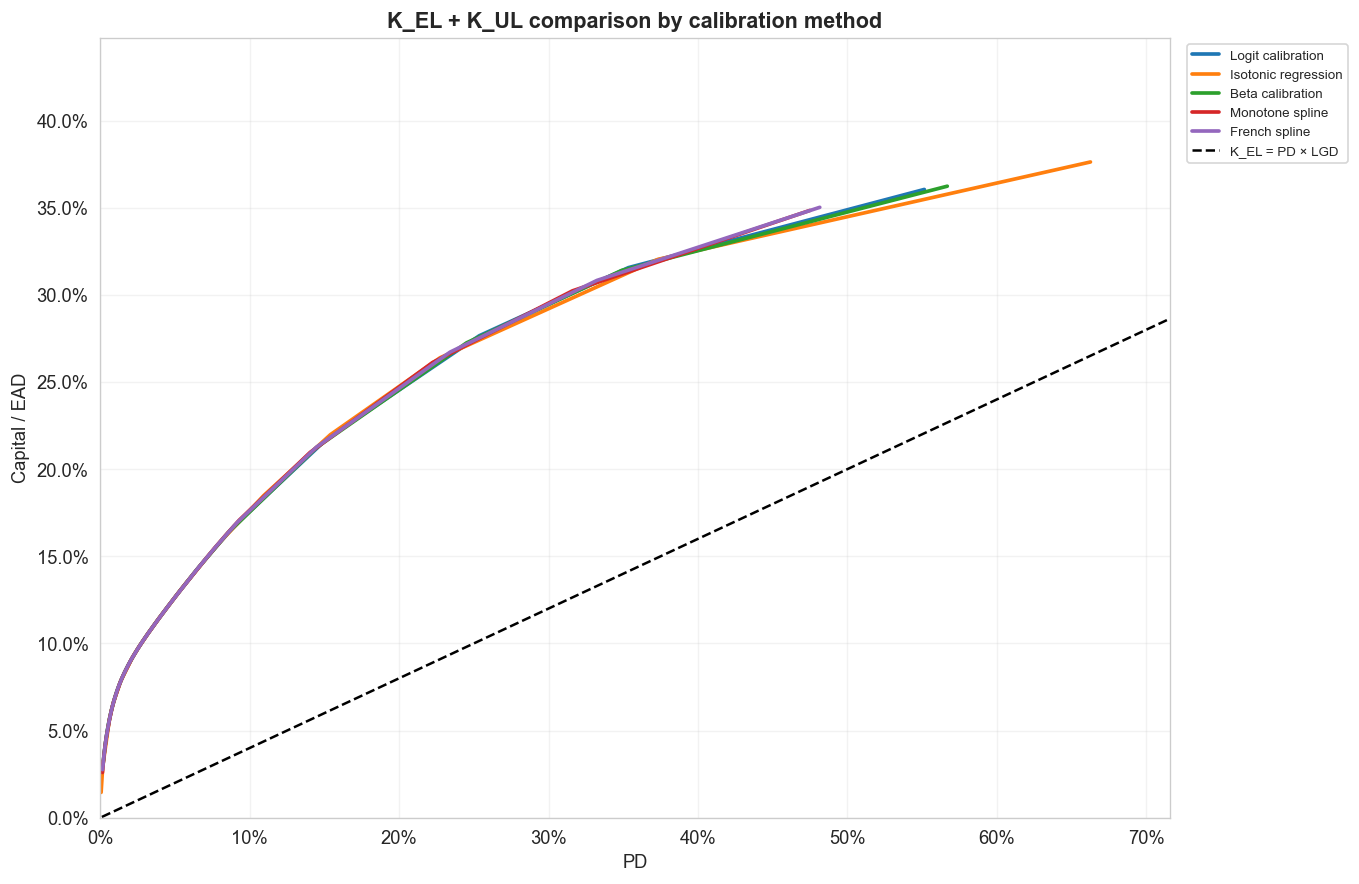

,avg_pd,avg_k_el_ratio,avg_k_ul_ratio,avg_k_total_ratio,max_pd
method,,,,,
Logit calibration,4.91%,1.96%,7.73%,9.70%,93.53%
Isotonic regression,4.91%,1.97%,7.45%,9.42%,100.00%
Beta calibration,4.90%,1.96%,7.82%,9.78%,96.61%
Monotone spline,4.67%,1.87%,7.85%,9.72%,52.12%
French spline,4.70%,1.88%,7.82%,9.70%,51.89%


In [27]:
def build_capital_curve(pd_values, assumptions, n_bins=40):
    """Build a smoothed empirical PD -> EL/UL/total capital curve."""
    pd_values = np.clip(np.asarray(pd_values, dtype=float), 1e-6, 1 - 1e-6)
    pd_values = np.sort(pd_values)

    tmp = calculate_irb_capital(pd_values, assumptions=assumptions).copy()
    tmp["k_el_ratio"] = tmp["expected_loss"] / tmp["ead"]
    tmp["k_ul_ratio"] = tmp["unexpected_loss_capital"] / tmp["ead"]
    tmp["k_total_ratio"] = tmp["k_el_ratio"] + tmp["k_ul_ratio"]

    if n_bins is not None and len(tmp) > n_bins:
        tmp["pd_bin"] = pd.qcut(tmp["pd"], q=n_bins, duplicates="drop")
        curve = (
            tmp.groupby("pd_bin", observed=True)
            .agg(
                pd=("pd", "mean"),
                k_el_ratio=("k_el_ratio", "mean"),
                k_ul_ratio=("k_ul_ratio", "mean"),
                k_total_ratio=("k_total_ratio", "mean"),
                n=("pd", "size"),
            )
            .reset_index(drop=True)
            .sort_values("pd")
        )
    else:
        curve = tmp[["pd", "k_el_ratio", "k_ul_ratio", "k_total_ratio"]].copy()

    return curve

capital_curves = {
    method: build_capital_curve(probs, capital_assumptions, n_bins=40)
    for method, probs in capital_methods.items()
}

n_methods = len(capital_curves)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (method, curve) in enumerate(capital_curves.items()):
    ax = axes[i]
    ax.fill_between(
        curve["pd"],
        0,
        curve["k_el_ratio"],
        color="#173f8a",
        alpha=0.95,
        label="K_EL = EL / EAD",
    )
    ax.fill_between(
        curve["pd"],
        curve["k_el_ratio"],
        curve["k_total_ratio"],
        color="lightgray",
        alpha=0.95,
        label="K_UL = UL capital / EAD",
    )
    ax.plot(curve["pd"], curve["k_total_ratio"], color="black", linewidth=1.5)
    ax.set_title(method, fontsize=11)
    ax.set_xlabel("PD")
    ax.set_ylabel("Capital / EAD")
    ax.set_xlim(0, min(1.0, curve["pd"].max() * 1.03))
    ax.set_ylim(0, max(0.35, curve["k_total_ratio"].max() * 1.08))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(True, alpha=0.25)
    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Total EL + UL capital load by PD calibration method",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

max_curve_pd = max(float(curve["pd"].max()) for curve in capital_curves.values())
max_curve_capital = max(float(curve["k_total_ratio"].max()) for curve in capital_curves.values())
pd_grid = np.linspace(0.001, max(0.999, max_curve_pd), 300)
k_el_grid = pd_grid * capital_assumptions.lgd

fig, ax = plt.subplots(figsize=(14, 7.5))
for method, curve in capital_curves.items():
    ax.plot(curve["pd"], curve["k_total_ratio"], linewidth=2.2, label=method)
ax.plot(pd_grid, k_el_grid, linestyle="--", color="black", linewidth=1.5, label="K_EL = PD × LGD")

ax.set_title("K_EL + K_UL comparison by calibration method", fontsize=13, fontweight="bold")
ax.set_xlabel("PD")
ax.set_ylabel("Capital / EAD")
ax.set_xlim(0, min(1.0, max_curve_pd * 1.08))
ax.set_ylim(0, max(max_curve_capital, float(k_el_grid.max())) * 1.12)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

capital_curve_summary = []
for method, probs in capital_methods.items():
    tmp = calculate_irb_capital(probs, assumptions=capital_assumptions).copy()
    capital_curve_summary.append({
        "method": method,
        "avg_pd": np.mean(tmp["pd"]),
        "avg_k_el_ratio": np.mean(tmp["expected_loss"] / tmp["ead"]),
        "avg_k_ul_ratio": np.mean(tmp["unexpected_loss_capital"] / tmp["ead"]),
        "avg_k_total_ratio": np.mean((tmp["expected_loss"] + tmp["unexpected_loss_capital"]) / tmp["ead"]),
        "max_pd": np.max(tmp["pd"]),
    })
capital_curve_summary = pd.DataFrame(capital_curve_summary).set_index("method")

display(
    capital_curve_summary.style.format({
        "avg_pd": "{:.2%}",
        "avg_k_el_ratio": "{:.2%}",
        "avg_k_ul_ratio": "{:.2%}",
        "avg_k_total_ratio": "{:.2%}",
        "max_pd": "{:.2%}",
    })
)


## 9. Final Conclusions, Practical Interpretation, and Limitations

The final conclusion combines four layers of analysis: statistical PD metrics, expected-default backtesting, impact on reserves/RWA/capital, and method behavior on the master scale. RF is treated here as a base way to produce a raw score/raw PD, not as a calibration model. The capital comparison uses logit calibration as the benchmark.


In [28]:
print("=" * 90)
print("FINAL COMPARISON OF CALIBRATED PD METHODS")
print("=" * 90)

calibrated_method_names = [name for name in calibrated_probs if name in df_results.index]
df_results_calibrated = df_results.loc[calibrated_method_names].copy()

metric_cols = [
    "brier_score",
    "log_loss",
    "ece_uniform",
    "ece_quantile",
    "hl_p_value",
    "cal_slope",
    "cal_intercept",
]
metric_cols = [col for col in metric_cols if col in df_results_calibrated.columns]
df_metrics_final = (
    df_results_calibrated[metric_cols]
    .sort_values(["brier_score", "log_loss", "ece_quantile"])
    .copy()
)

print("1. Statistical metrics for calibrated PD on OOT 2024")
display(
    df_metrics_final.style.format({
        "brier_score": "{:.5f}",
        "log_loss": "{:.5f}",
        "ece_uniform": "{:.5f}",
        "ece_quantile": "{:.5f}",
        "hl_p_value": "{:.3f}",
        "cal_slope": "{:.3f}",
        "cal_intercept": "{:.3f}",
    })
)

if "backtest_table" in globals():
    df_backtest_calibrated = backtest_table.loc[
        [name for name in calibrated_method_names if name in backtest_table.index]
    ].sort_values("abs_default_gap")
    print("2. Expected-default backtesting by calibrated PD")
    display(
        df_backtest_calibrated.style.format({
            "avg_pd": "{:.2%}",
            "expected_defaults": "{:.2f}",
            "default_gap": "{:.2f}",
            "abs_default_gap": "{:.2f}",
            "relative_default_gap_pct": "{:.2%}",
            "calibration_ratio": "{:.2f}",
            "actual_default_rate": "{:.2%}",
            "predicted_default_rate": "{:.2%}",
        })
    )
else:
    df_backtest_calibrated = None

capital_cols = [
    "avg_pd",
    "total_expected_loss",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    "h1_0_if_keep_logit_capital",
]
capital_cols = [col for col in capital_cols if col in df_rwa.columns]
capital_summary_final = df_rwa[capital_cols].copy()
for money_col in ["total_expected_loss", "total_rwa", "total_required_capital"]:
    if money_col in capital_summary_final.columns:
        capital_summary_final[money_col] = capital_summary_final[money_col] / 1_000_000_000
capital_summary_final = capital_summary_final.rename(columns={
    "avg_pd": "Mean PD",
    "total_expected_loss": "Expected loss, bn",
    "total_rwa": "RWA, bn",
    "total_required_capital": "Required capital, bn",
    "rwa_saving_vs_baseline_pct": "RWA reduction vs logit",
    "h1_0_if_keep_logit_capital": "H1.0 with logit capital",
})

print("3. EL, RWA, and capital impact by individual PD")
display(
    capital_summary_final.style.format({
        "Mean PD": "{:.2%}",
        "Expected loss, bn": "{:.3f}",
        "RWA, bn": "{:.3f}",
        "Required capital, bn": "{:.3f}",
        "RWA reduction vs logit": "{:.2%}",
        "H1.0 with logit capital": "{:.2%}",
    })
)

best_brier = df_metrics_final["brier_score"].idxmin()
best_logloss = df_metrics_final["log_loss"].idxmin()
best_ece = df_metrics_final["ece_quantile"].idxmin()
best_slope = (df_metrics_final["cal_slope"] - 1.0).abs().idxmin()
best_backtest = (
    df_backtest_calibrated["abs_default_gap"].idxmin()
    if df_backtest_calibrated is not None and not df_backtest_calibrated.empty
    else "not calculated"
)
best_rwa = df_rwa["total_rwa"].idxmin()

if "fixed_master_scale_rwa_summary" in globals():
    best_fixed_scale_rwa_reduction = fixed_master_scale_rwa_summary["rwa_saving_vs_logit_pct"].idxmax()
else:
    best_fixed_scale_rwa_reduction = "not calculated"

criteria_summary = pd.DataFrame([
    {
        "Criterion": "Minimum Brier Score",
        "Best method": best_brier,
        "Value": df_metrics_final.loc[best_brier, "brier_score"],
        "Interpretation": "Best average probability-forecast quality among calibrators.",
    },
    {
        "Criterion": "Minimum Log-Loss",
        "Best method": best_logloss,
        "Value": df_metrics_final.loc[best_logloss, "log_loss"],
        "Interpretation": "Best result after penalizing confident errors.",
    },
    {
        "Criterion": "Minimum ECE on quantile bins",
        "Best method": best_ece,
        "Value": df_metrics_final.loc[best_ece, "ece_quantile"],
        "Interpretation": "Best alignment of predicted PD with observed defaults across risk groups.",
    },
    {
        "Criterion": "Calibration slope closest to 1",
        "Best method": best_slope,
        "Value": df_metrics_final.loc[best_slope, "cal_slope"],
        "Interpretation": "PD sensitivity to actual risk is closest to one.",
    },
    {
        "Criterion": "Minimum expected-default gap",
        "Best method": best_backtest,
        "Value": (
            df_backtest_calibrated.loc[best_backtest, "abs_default_gap"]
            if df_backtest_calibrated is not None and best_backtest != "not calculated"
            else np.nan
        ),
        "Interpretation": "Closest to the actual number of defaults on OOT 2024.",
    },
    {
        "Criterion": "Minimum RWA by individual PD",
        "Best method": best_rwa,
        "Value": df_rwa.loc[best_rwa, "total_rwa"],
        "Interpretation": "Lowest IRB-style capital load at borrower level.",
    },
    {
        "Criterion": "RWA reduction on fixed master scale vs logit",
        "Best method": best_fixed_scale_rwa_reduction,
        "Value": (
            fixed_master_scale_rwa_summary.loc[best_fixed_scale_rwa_reduction, "rwa_saving_vs_logit_pct"]
            if "fixed_master_scale_rwa_summary" in globals() and best_fixed_scale_rwa_reduction != "not calculated"
            else np.nan
        ),
        "Interpretation": "Percent RWA reduction after assigning borrowers to external A1...E PD buckets.",
    },
])

print("4. Best methods by individual criterion")
display(
    criteria_summary.style.format({
        "Value": lambda x: "" if pd.isna(x) else f"{x:,.5f}" if abs(x) < 1 else f"{x:,.2f}",
    })
)

actual_defaults_text = f"{actual_defaults:.0f}" if "actual_defaults" in globals() else "not calculated"
oot_default_rate_text = f"{y_test.mean():.2%}" if "y_test" in globals() else "not calculated"
individual_rwa_reduction_text = (
    f"{df_rwa.loc[best_rwa, 'rwa_saving_vs_baseline_pct']:.2%}"
    if "rwa_saving_vs_baseline_pct" in df_rwa.columns
    else "not calculated"
)
fixed_rwa_reduction_text = (
    f"{fixed_master_scale_rwa_summary.loc[best_fixed_scale_rwa_reduction, 'rwa_saving_vs_logit_pct']:.2%}"
    if "fixed_master_scale_rwa_summary" in globals() and best_fixed_scale_rwa_reduction != "not calculated"
    else "not calculated"
)
final_845_method = final_pd_method if "final_pd_method" in globals() else best_backtest
target_ct_text = f"{TARGET_CT:.2%}" if "TARGET_CT" in globals() else "not calculated"

print("=" * 90)
print("FINAL CONCLUSION")
print("=" * 90)
print(
    "1. RF is not treated as a calibration model in the RWA block; it is the base source "
    "of the raw score/raw PD. Logit calibration is the benchmark for economic comparison."
)
print(
    f"2. On OOT 2024, the observed default rate is {oot_default_rate_text} "
    f"({actual_defaults_text} defaults). Among calibrated methods, the best statistical results are: "
    f"Brier = {best_brier}, Log-Loss = {best_logloss}, ECE = {best_ece}, slope = {best_slope}."
)
if best_backtest != "not calculated":
    print(
        f"3. Expected-default backtesting is led by {best_backtest}. This criterion matters for business "
        "interpretation because a method with a strong Brier or Log-Loss does not necessarily match the "
        "total number of portfolio defaults most closely."
    )
print(
    f"4. In the individual IRB-style calculation, the lowest RWA among calibrators is produced by {best_rwa}; "
    f"its RWA reduction versus logit is {individual_rwa_reduction_text}. Capital reduction should be read "
    "together with expected-default and reliability diagnostics."
)
print(
    f"5. On the fixed master scale, the main metric is now percent RWA reduction versus logit. "
    f"The best value is produced by {best_fixed_scale_rwa_reduction}: {fixed_rwa_reduction_text}."
)
if "binomial_ztest_summary" in globals():
    ztest_best = binomial_ztest_summary["significant_bins_5pct"].idxmin()
    ztest_best_count = int(binomial_ztest_summary.loc[ztest_best, "significant_bins_5pct"])
    print(
        f"6. Bucket-level z-stat by quantile PD bins works as a reliability guardrail. "
        f"The fewest significant 5% deviations are produced by {ztest_best}: {ztest_best_count} bins."
    )
if "master_scale_ztest_summary" in globals():
    master_ztest_col = (
        "significant_buckets_5pct"
        if "significant_buckets_5pct" in master_scale_ztest_summary.columns
        else "significant_bins_5pct"
    )
    master_ztest_best = master_scale_ztest_summary[master_ztest_col].idxmin()
    master_ztest_best_count = int(master_scale_ztest_summary.loc[master_ztest_best, master_ztest_col])
    print(
        f"7. The fixed master-scale binomial test shows where A1...E buckets statistically diverge "
        f"from the external rating PD. The fewest significant buckets are produced by "
        f"{master_ztest_best}: {master_ztest_best_count}."
    )
print(
    "8. AUC / Gini / KS change little after calibration because most calibrators preserve borrower ordering "
    "and mainly adjust the PD level. The main effect is therefore visible in calibration metrics, expected "
    "defaults, bucket-level z-stat diagnostics, and RWA rather than in ranking metrics."
)
print(
    f"9. Rating Master Scale A1...E is a separate analysis layer: the rating PD curve is shifted to the "
    f"in-time target CT ({target_ct_text}). Fixed master-scale buckets show how individual PDs from different "
    "calibrators redistribute borrowers across external PD boundaries."
)
print(
    f"10. The illustrative final PD reserve/capital calculation uses {final_845_method}. This keeps the final "
    "choice aligned with expected-default backtesting among calibrated methods."
)
print(
    "11. Practical takeaway: compare four blocks together: PD statistics, expected-default backtesting, "
    "bucket-level z-stat diagnostics, and the RWA/H1.0 effect versus logit. A workable candidate should offer "
    "a reasonable compromise between matching defaults, maintaining a stable reliability profile, and producing "
    "an economically explainable capital impact."
)


FINAL COMPARISON OF CALIBRATED PD METHODS
1. Statistical metrics for calibrated PD on OOT 2024


,brier_score,log_loss,ece_uniform,ece_quantile,hl_p_value,cal_slope,cal_intercept
method,,,,,,,
Beta calibration,0.03400,0.13037,0.00529,0.00580,0.007,0.966,-0.119
Isotonic regression,0.03402,0.13332,0.00297,0.00468,0.000,0.913,-0.229
Logit calibration,0.03408,0.13060,0.00554,0.00572,0.002,0.963,-0.124
Monotone spline,0.03459,0.13207,0.00577,0.00591,0.000,1.039,0.095
French spline,0.03464,0.13196,0.00527,0.00457,0.000,1.017,0.043


2. Expected-default backtesting by calibrated PD


,n_obs,defaults,expected_defaults,default_gap,abs_default_gap,calibration_ratio,actual_default_rate,predicted_default_rate,avg_pd,relative_default_gap_pct
method,,,,,,,,,,
French spline,8776,415.000000,412.47,2.53,2.53,1.01,4.73%,4.70%,4.70%,0.61%
Monotone spline,8776,415.000000,409.72,5.28,5.28,1.01,4.73%,4.67%,4.67%,1.27%
Beta calibration,8776,415.000000,430.37,-15.37,15.37,0.96,4.73%,4.90%,4.90%,-3.70%
Logit calibration,8776,415.000000,430.96,-15.96,15.96,0.96,4.73%,4.91%,4.91%,-3.85%
Isotonic regression,8776,415.000000,431.23,-16.23,16.23,0.96,4.73%,4.91%,4.91%,-3.91%


3. EL, RWA, and capital impact by individual PD


,Mean PD,"Expected loss, bn","RWA, bn","Required capital, bn",RWA reduction vs logit,H1.0 with logit capital
method,,,,,,
Logit calibration,4.91%,0.172,8.485,0.679,0.00%,8.00%
Isotonic regression,4.91%,0.173,8.178,0.654,3.62%,8.30%
Beta calibration,4.90%,0.172,8.579,0.686,-1.11%,7.91%
Monotone spline,4.67%,0.164,8.617,0.689,-1.56%,7.88%
French spline,4.70%,0.165,8.577,0.686,-1.08%,7.91%


4. Best methods by individual criterion


,Criterion,Best method,Value,Interpretation
0,Minimum Brier Score,Beta calibration,0.03400,Best average probability-forecast quality among calibrators.
1,Minimum Log-Loss,Beta calibration,0.13037,Best result after penalizing confident errors.
2,Minimum ECE on quantile bins,French spline,0.00457,Best alignment of predicted PD with observed defaults across risk groups.
3,Calibration slope closest to 1,French spline,1.02,PD sensitivity to actual risk is closest to one.
4,Minimum expected-default gap,French spline,2.53,Closest to the actual number of defaults on OOT 2024.
5,Minimum RWA by individual PD,Isotonic regression,"8,177,687,519.26",Lowest IRB-style capital load at borrower level.
6,RWA reduction on fixed master scale vs logit,Isotonic regression,0.04121,Percent RWA reduction after assigning borrowers to external A1...E PD buckets.


FINAL CONCLUSION
1. RF is not treated as a calibration model in the RWA block; it is the base source of the raw score/raw PD. Logit calibration is the benchmark for economic comparison.
2. On OOT 2024, the observed default rate is 4.73% (415 defaults). Among calibrated methods, the best statistical results are: Brier = Beta calibration, Log-Loss = Beta calibration, ECE = French spline, slope = French spline.
3. Expected-default backtesting is led by French spline. This criterion matters for business interpretation because a method with a strong Brier or Log-Loss does not necessarily match the total number of portfolio defaults most closely.
4. In the individual IRB-style calculation, the lowest RWA among calibrators is produced by Isotonic regression; its RWA reduction versus logit is 3.62%. Capital reduction should be read together with expected-default and reliability diagnostics.
5. On the fixed master scale, the main metric is now percent RWA reduction versus logit. The best value 